# SHL Grammar Scoring Engine — Expert Experiment Notebook

This notebook keeps the working SHL pipeline and adds a few stronger, still explainable experiments.

**Current Kaggle benchmark to beat: 0.4401 RMSE.**

Main idea:

`audio -> transcript + word timing + acoustic features + speech embeddings -> diverse small models -> leakage-safe OOF stack -> submission`

New experiments in this version:

1. Rich Whisper word-timing features: speaking rate, pauses, word duration and ASR confidence.
2. GPT-2 token surprisal statistics instead of using only one perplexity number.
3. RBF-SVR and KNN on WavLM embeddings, not only Ridge.
4. HuBERT speech embeddings as a third frozen speech representation.
5. Unsupervised train/test domain weighting so the model focuses more on training clips that look like test clips.
6. Cross-fitted stacking with base predictions plus a few simple meta-features.
7. A small rounding check because the labels are in 0.5 steps.

I do not use filename numbers as features. I do not use test labels.

## What changed in this version
1. **Crash fixed.** The stack used the names `whisper`/`hubert`, the full-data models used `whisper_best`/`hubert_best` (`KeyError: 'whisper'`).
2. **Stack fitted on the right inputs.** The final meta-model is now trained on out-of-fold base predictions, the same kind of input it was validated on. Before, it was refitted on in-sample predictions.
3. **Removed the train-vs-test probability from the meta features.** It was computed by a classifier that had seen both sets, so test clips always looked more "test-like" than train clips by construction.
4. **New base model:** WavLM + Whisper + HuBERT in one RBF-SVR.
5. **Predictions rounded to 2 decimals** (harmless; the rounding check showed no real gain).
6. **Sanity cell** after the submission: file format, closeness to the best single model, and noise of the stack score.


## 1. Setup

I keep the package list close to the working notebook. The cache folder means that expensive Whisper/WavLM/Whisper-encoder features can be reused when the Kaggle session keeps `/kaggle/working`.

In [2]:
%pip install -q faster-whisper sentence-transformers language_tool_python lightgbm transformers librosa joblib

print("Packages are ready.")

Note: you may need to restart the kernel to use updated packages.
Packages are ready.


In [3]:
import os
import re
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy.stats import pearsonr

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression

from lightgbm import LGBMRegressor, LGBMClassifier

import torch

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# The old generic MiniLM experiment was not a strong contributor.
# Keep it off by default to save time. Turn it on only for an extra experiment.
RUN_MINILM = False

CACHE_DIR = Path("/kaggle/working/shl_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Cache:", CACHE_DIR)

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
Cache: /kaggle/working/shl_cache


## 2. Find the Kaggle data

I do not hard-code only one path. Kaggle can mount competition data differently between sessions.

In [4]:
def find_dataset_root():
    known = Path("/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final")
    if (known / "train.csv").exists() and (known / "test.csv").exists():
        return known

    input_root = Path("/kaggle/input")
    candidates = []
    if input_root.exists():
        for root, dirs, files in os.walk(input_root):
            fs = set(files)
            if "train.csv" in fs and "test.csv" in fs:
                candidates.append(Path(root))

    if not candidates:
        print("No train.csv + test.csv pair was found under /kaggle/input.")
        if input_root.exists():
            print("Mounted folders:")
            for p in sorted(input_root.iterdir()):
                print(" -", p)
        raise FileNotFoundError("Attach the SHL competition dataset to this Kaggle notebook.")

    candidates = sorted(candidates, key=lambda p: ("Dataset_Final" not in p.name, len(str(p))))
    return candidates[0]

DATASET_ROOT = find_dataset_root()
TRAIN_CSV = DATASET_ROOT / "train.csv"
TEST_CSV = DATASET_ROOT / "test.csv"
AUDIO_TRAIN = DATASET_ROOT / "train"
AUDIO_TEST = DATASET_ROOT / "test"
SAMPLE_SUB_CSV = DATASET_ROOT / "sample_submission.csv"

print("DATASET_ROOT:", DATASET_ROOT)
print("Train CSV exists:", TRAIN_CSV.exists())
print("Test CSV exists :", TEST_CSV.exists())
print("Train audio exists:", AUDIO_TRAIN.exists())
print("Test audio exists :", AUDIO_TEST.exists())

DATASET_ROOT: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
Train CSV exists: True
Test CSV exists : True
Train audio exists: True
Test audio exists : True


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUB_CSV) if SAMPLE_SUB_CSV.exists() else None

ID_COL = "filename"
TARGET_COL = "label"
y = train_df[TARGET_COL].astype(float).to_numpy()

assert ID_COL in train_df.columns and ID_COL in test_df.columns
assert len(train_df) == 769
assert len(test_df) == 216

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())
if sample_submission is not None:
    print("Sample submission shape:", sample_submission.shape)
    print("Sample columns:", sample_submission.columns.tolist())

print("\nLabel distribution:")
print(train_df[TARGET_COL].value_counts().sort_index())

Train shape: (769, 2)
Test shape : (216, 2)
Train columns: ['filename', 'label']
Test columns : ['filename', 'label']
Sample submission shape: (204, 2)
Sample columns: ['filename', 'label']

Label distribution:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


## 3. Metrics and first visualization

RMSE is the main metric because the Kaggle leaderboard is lower-is-better. I also report Pearson correlation because the challenge description mentions it.

Predict the mean: RMSE=1.2382 | Pearson=nan


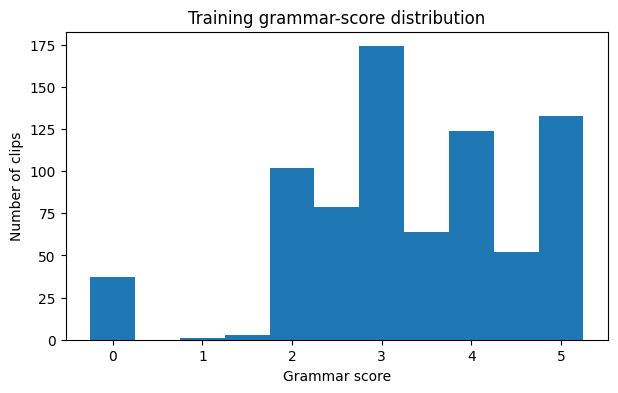

In [6]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def pearson(y_true, y_pred):
    return float(pearsonr(y_true, y_pred)[0])


def describe_result(name, y_true, y_pred):
    print(f"{name}: RMSE={rmse(y_true, y_pred):.4f} | Pearson={pearson(y_true, y_pred):.4f}")

mean_pred = np.full(len(y), y.mean())
describe_result("Predict the mean", y, mean_pred)

plt.figure(figsize=(7, 4))
plt.hist(y, bins=np.arange(-0.25, 5.26, 0.5))
plt.xlabel("Grammar score")
plt.ylabel("Number of clips")
plt.title("Training grammar-score distribution")
plt.show()

## 4. Whisper transcription

Faster-Whisper `small` is used only for transcription. I load audio with librosa first and pass the NumPy array to Whisper because direct file loading caused a PyAV issue in the earlier notebook.

In [7]:
import librosa

_whisper_model = None


def get_whisper_model():
    global _whisper_model
    if _whisper_model is None:
        from faster_whisper import WhisperModel
        if DEVICE == "cuda":
            _whisper_model = WhisperModel("small", device="cuda", compute_type="float16")
        else:
            _whisper_model = WhisperModel("small", device="cpu", compute_type="int8")
    return _whisper_model


def transcribe_one(path):
    audio, _ = librosa.load(path, sr=16000, mono=True)
    audio = audio.astype(np.float32)

    segments, _ = get_whisper_model().transcribe(
        audio,
        language="en",
        beam_size=5,
        condition_on_previous_text=False,
        word_timestamps=False,
    )
    segments = list(segments)
    text = " ".join(s.text.strip() for s in segments).strip()

    if segments:
        starts = np.array([float(s.start) for s in segments])
        ends = np.array([float(s.end) for s in segments])
        gaps = starts[1:] - ends[:-1] if len(segments) > 1 else np.array([])
        real_gaps = gaps[gaps >= 0]
        logprob = [float(s.avg_logprob) for s in segments if s.avg_logprob is not None]
        no_speech = [float(s.no_speech_prob) for s in segments if s.no_speech_prob is not None]
        compression = [float(s.compression_ratio) for s in segments if s.compression_ratio is not None]

        meta = {
            "whisper_segment_count": len(segments),
            "whisper_last_end": float(ends[-1]),
            "whisper_pause_count": int(np.sum(real_gaps >= 0.5)),
            "whisper_pause_mean": float(np.mean(real_gaps[real_gaps >= 0.5])) if np.any(real_gaps >= 0.5) else 0.0,
            "whisper_pause_max": float(real_gaps.max()) if len(real_gaps) else 0.0,
            "whisper_avg_logprob": float(np.mean(logprob)) if logprob else 0.0,
            "whisper_no_speech_prob": float(np.mean(no_speech)) if no_speech else 0.0,
            "whisper_compression_ratio": float(np.mean(compression)) if compression else 0.0,
        }
    else:
        meta = {
            "whisper_segment_count": 0,
            "whisper_last_end": 0.0,
            "whisper_pause_count": 0,
            "whisper_pause_mean": 0.0,
            "whisper_pause_max": 0.0,
            "whisper_avg_logprob": 0.0,
            "whisper_no_speech_prob": 1.0,
            "whisper_compression_ratio": 0.0,
        }

    return text, meta


def whisper_table(frame, audio_dir, cache_name):
    cache_path = CACHE_DIR / f"{cache_name}.csv"
    if cache_path.exists():
        cached = pd.read_csv(cache_path).fillna("")
        if set(cached[ID_COL].astype(str)) == set(frame[ID_COL].astype(str)):
            return cached.set_index(ID_COL).loc[frame[ID_COL]].reset_index()

    rows = []
    for filename in tqdm(frame[ID_COL], desc=f"Whisper {cache_name}"):
        try:
            text, meta = transcribe_one(audio_dir / filename)
        except Exception as e:
            print("Whisper error:", filename, e)
            text, meta = "", {
                "whisper_segment_count": 0,
                "whisper_last_end": 0.0,
                "whisper_pause_count": 0,
                "whisper_pause_mean": 0.0,
                "whisper_pause_max": 0.0,
                "whisper_avg_logprob": 0.0,
                "whisper_no_speech_prob": 1.0,
                "whisper_compression_ratio": 0.0,
            }
        rows.append({ID_COL: filename, "transcript": text, **meta})

    out = pd.DataFrame(rows)
    out.to_csv(cache_path, index=False)
    return out

whisper_train = whisper_table(train_df, AUDIO_TRAIN, "whisper_train")
whisper_test = whisper_table(test_df, AUDIO_TEST, "whisper_test")

train_texts = whisper_train["transcript"].fillna("").tolist()
test_texts = whisper_test["transcript"].fillna("").tolist()

print("Train transcripts:", len(train_texts))
print("Test transcripts :", len(test_texts))
print("Empty train transcripts:", sum(t.strip() == "" for t in train_texts))
print("Empty test transcripts :", sum(t.strip() == "" for t in test_texts))

del _whisper_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    _whisper_model = None

Whisper whisper_train:   0%|          | 0/769 [00:00<?, ?it/s]

Whisper whisper_test:   0%|          | 0/216 [00:00<?, ?it/s]

Train transcripts: 769
Test transcripts : 216
Empty train transcripts: 0
Empty test transcripts : 0


## 5. Text and grammar features

I use simple features first, then grammar-specific pretrained scores.

In [8]:
FILLERS = {"um", "uh", "erm", "hmm", "mm", "like", "actually", "basically"}


def basic_features(text):
    text = str(text).strip()
    lower = text.lower()
    words = re.findall(r"\b[a-zA-Z']+\b", lower)
    n_words = len(words)
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    n_sentences = max(len(sentences), 1)

    if n_words == 0:
        return {
            "word_count": 0.0,
            "sentence_count": 0.0,
            "avg_sentence_length": 0.0,
            "avg_word_length": 0.0,
            "unique_word_ratio": 0.0,
            "repetition_count": 0.0,
            "filler_count": 0.0,
            "filler_ratio": 0.0,
        }

    filler_count = sum(w in FILLERS for w in words) + len(re.findall(r"\byou know\b", lower))
    repetition_count = sum(words[i] == words[i - 1] for i in range(1, n_words))

    return {
        "word_count": float(n_words),
        "sentence_count": float(n_sentences),
        "avg_sentence_length": float(n_words / n_sentences),
        "avg_word_length": float(np.mean([len(w) for w in words])),
        "unique_word_ratio": float(len(set(words)) / n_words),
        "repetition_count": float(repetition_count),
        "filler_count": float(filler_count),
        "filler_ratio": float(filler_count / n_words),
    }

basic_train = pd.DataFrame([basic_features(t) for t in train_texts])
basic_test = pd.DataFrame([basic_features(t) for t in test_texts])
print(basic_train.describe().T.round(3))

                     count    mean     std    min     25%      50%      75%  \
word_count           769.0  99.635  27.291  3.000  81.000  101.000  121.000   
sentence_count       769.0   4.701   2.745  1.000   3.000    4.000    6.000   
avg_sentence_length  769.0  31.139  26.081  3.000  16.000   21.667   33.667   
avg_word_length      769.0   4.220   0.412  3.320   3.934    4.181    4.438   
unique_word_ratio    769.0   0.609   0.093  0.388   0.544    0.602    0.664   
repetition_count     769.0   0.382   0.876  0.000   0.000    0.000    1.000   
filler_count         769.0   1.074   1.720  0.000   0.000    1.000    1.000   
filler_ratio         769.0   0.011   0.019  0.000   0.000    0.007    0.014   

                         max  
word_count           171.000  
sentence_count        15.000  
avg_sentence_length  149.000  
avg_word_length        5.847  
unique_word_ratio      1.000  
repetition_count      12.000  
filler_count          16.000  
filler_ratio           0.278  


In [9]:
# LanguageTool features
import language_tool_python

lt = language_tool_python.LanguageTool("en-US")

def language_tool_features(text):
    text = str(text)
    words = max(len(re.findall(r"\b[a-zA-Z']+\b", text)), 1)
    sentences = max(len([s for s in re.split(r"[.!?]+", text) if s.strip()]), 1)
    matches = lt.check(text)

    grammar = sum(1 for m in matches if getattr(m, "ruleIssueType", "") == "grammar")
    spelling = sum(1 for m in matches if getattr(m, "ruleIssueType", "") == "misspelling")
    style = sum(1 for m in matches if getattr(m, "ruleIssueType", "") == "style")

    return {
        "lt_total_errors": float(len(matches)),
        "lt_grammar_errors": float(grammar),
        "lt_spelling_errors": float(spelling),
        "lt_style_errors": float(style),
        "lt_errors_per_100_words": float(len(matches) / words * 100),
        "lt_grammar_errors_per_sentence": float(grammar / sentences),
    }

def build_lt(texts, name):
    p = CACHE_DIR / f"{name}.csv"
    if p.exists():
        return pd.read_csv(p)
    table = pd.DataFrame([language_tool_features(t) for t in tqdm(texts, desc=name)])
    table.to_csv(p, index=False)
    return table

languagetool_train = build_lt(train_texts, "languagetool_train")
languagetool_test = build_lt(test_texts, "languagetool_test")
print(languagetool_train.describe().T.round(3))

languagetool_train:   0%|          | 0/769 [00:00<?, ?it/s]

languagetool_test:   0%|          | 0/216 [00:00<?, ?it/s]

                                count  mean    std  min    25%    50%    75%  \
lt_total_errors                 769.0  2.44  2.248  0.0  1.000  2.000  3.000   
lt_grammar_errors               769.0  0.00  0.000  0.0  0.000  0.000  0.000   
lt_spelling_errors              769.0  0.00  0.000  0.0  0.000  0.000  0.000   
lt_style_errors                 769.0  0.00  0.000  0.0  0.000  0.000  0.000   
lt_errors_per_100_words         769.0  2.49  2.266  0.0  0.901  2.041  3.571   
lt_grammar_errors_per_sentence  769.0  0.00  0.000  0.0  0.000  0.000  0.000   

                                   max  
lt_total_errors                 15.000  
lt_grammar_errors                0.000  
lt_spelling_errors               0.000  
lt_style_errors                  0.000  
lt_errors_per_100_words         14.667  
lt_grammar_errors_per_sentence   0.000  


In [10]:
# GPT-2 perplexity
from transformers import AutoTokenizer, AutoModelForCausalLM

gpt2_name = "gpt2"
gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_name)
gpt2_model = AutoModelForCausalLM.from_pretrained(gpt2_name).to(DEVICE).eval()

@torch.no_grad()
def gpt2_ppl(text):
    text = str(text).strip()
    if not text:
        return 0.0
    encoded = gpt2_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)
    loss = gpt2_model(**encoded, labels=encoded["input_ids"]).loss
    return float(torch.exp(loss).detach().cpu())

def build_ppl(texts, name):
    p = CACHE_DIR / f"{name}.csv"
    if p.exists():
        return pd.read_csv(p)
    values = [gpt2_ppl(t) for t in tqdm(texts, desc=name)]
    out = pd.DataFrame({"gpt2_perplexity": values})
    out["log_gpt2_perplexity"] = np.log1p(out["gpt2_perplexity"])
    out.to_csv(p, index=False)
    return out

gpt2_train = build_ppl(train_texts, "gpt2_train")
gpt2_test = build_ppl(test_texts, "gpt2_test")
print(gpt2_train.describe().T.round(3))

del gpt2_model, gpt2_tokenizer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

gpt2_train:   0%|          | 0/769 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


gpt2_test:   0%|          | 0/216 [00:00<?, ?it/s]

                     count    mean    std     min     25%     50%     75%  \
gpt2_perplexity      769.0  44.401  31.51  10.568  25.940  36.758  51.394   
log_gpt2_perplexity  769.0   3.668   0.51   2.448   3.294   3.631   3.959   

                         max  
gpt2_perplexity      358.002  
log_gpt2_perplexity    5.883  


In [11]:
# RoBERTa-CoLA grammatical acceptability
from transformers import AutoTokenizer, AutoModelForSequenceClassification

cola_name = "textattack/roberta-base-CoLA"
cola_tokenizer = AutoTokenizer.from_pretrained(cola_name)
cola_model = AutoModelForSequenceClassification.from_pretrained(cola_name).to(DEVICE).eval()


def split_sentences(text):
    parts = re.split(r"(?<=[.!?])\s+", str(text))
    return [s.strip() for s in parts if len(re.findall(r"[A-Za-z']+", s)) >= 3]

@torch.no_grad()
def cola_scores(sentences):
    if not sentences:
        return np.array([], dtype=float)
    scores = []
    for start in range(0, len(sentences), 32):
        batch = sentences[start:start + 32]
        enc = cola_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(DEVICE)
        probs = torch.softmax(cola_model(**enc).logits, dim=-1)[:, 1]
        scores.extend(probs.detach().cpu().numpy().tolist())
    return np.asarray(scores, dtype=float)


def cola_features(text):
    scores = cola_scores(split_sentences(text))
    if len(scores) == 0:
        return {"cola_mean": 0.0, "cola_min": 0.0, "cola_bad_fraction": 0.0, "cola_sentence_count": 0.0}
    return {
        "cola_mean": float(scores.mean()),
        "cola_min": float(scores.min()),
        "cola_bad_fraction": float((scores < 0.5).mean()),
        "cola_sentence_count": float(len(scores)),
    }

def build_cola(texts, name):
    p = CACHE_DIR / f"{name}.csv"
    if p.exists():
        return pd.read_csv(p)
    out = pd.DataFrame([cola_features(t) for t in tqdm(texts, desc=name)])
    out.to_csv(p, index=False)
    return out

cola_train = build_cola(train_texts, "cola_train")
cola_test = build_cola(test_texts, "cola_test")
print(cola_train.describe().T.round(3))

del cola_model, cola_tokenizer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

cola_train:   0%|          | 0/769 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

cola_test:   0%|          | 0/216 [00:00<?, ?it/s]

                     count   mean    std    min    25%    50%    75%     max
cola_mean            769.0  0.597  0.237  0.055  0.446  0.641  0.789   0.984
cola_min             769.0  0.303  0.234  0.037  0.129  0.212  0.407   0.984
cola_bad_fraction    769.0  0.420  0.341  0.000  0.143  0.333  0.667   1.000
cola_sentence_count  769.0  4.566  2.597  1.000  3.000  4.000  6.000  15.000


### Optional MiniLM experiment

The previous notebook found that MiniLM did not beat the stronger speech models. I leave it off by default to save time, but the block is here for completeness.

In [12]:
if RUN_MINILM:
    from sentence_transformers import SentenceTransformer
    minilm = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)
    minilm_train = minilm.encode(train_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    minilm_test = minilm.encode(test_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    np.save(CACHE_DIR / "minilm_train.npy", minilm_train)
    np.save(CACHE_DIR / "minilm_test.npy", minilm_test)
    del minilm
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
else:
    minilm_train = None
    minilm_test = None
    print("MiniLM skipped.")

MiniLM skipped.


## 6. Acoustic and fluency features

These are simple features that are easy to explain:

- duration and speech ratio
- pauses
- speaking rate
- energy
- zero-crossing rate
- spectral features
- pitch
- MFCC statistics
- Whisper timing/confidence

In [13]:
from joblib import Parallel, delayed


def audio_features(path):
    signal, sr = librosa.load(path, sr=16000, mono=True)
    signal = signal.astype(np.float32)
    duration = len(signal) / sr

    if len(signal) == 0:
        return {"a_duration": 0.0, "a_speech_seconds": 0.0, "a_speech_ratio": 0.0}

    intervals = librosa.effects.split(signal, top_db=30)
    speech_seconds = float(sum(end - start for start, end in intervals) / sr) if len(intervals) else 0.0

    gaps = (intervals[1:, 0] - intervals[:-1, 1]) / sr if len(intervals) > 1 else np.array([])
    gaps = gaps[gaps >= 0]
    pause_02 = gaps[gaps >= 0.2]
    pause_05 = gaps[gaps >= 0.5]
    pause_10 = gaps[gaps >= 1.0]

    rms = librosa.feature.rms(y=signal, frame_length=1024, hop_length=512)[0]
    zcr = librosa.feature.zero_crossing_rate(signal, frame_length=1024, hop_length=512)[0]
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr)[0]
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

    try:
        pitch = librosa.yin(signal, fmin=65, fmax=400, sr=sr)
        pitch = pitch[np.isfinite(pitch)]
    except Exception:
        pitch = np.array([])

    out = {
        "a_duration": float(duration),
        "a_speech_seconds": speech_seconds,
        "a_speech_ratio": float(speech_seconds / max(duration, 1e-6)),
        "a_segments": float(len(intervals)),
        "a_pause_02_count": float(len(pause_02)),
        "a_pause_05_count": float(len(pause_05)),
        "a_pause_10_count": float(len(pause_10)),
        "a_pause_total": float(pause_02.sum()) if len(pause_02) else 0.0,
        "a_pause_mean": float(pause_05.mean()) if len(pause_05) else 0.0,
        "a_pause_max": float(gaps.max()) if len(gaps) else 0.0,
        "a_rms_mean": float(rms.mean()),
        "a_rms_std": float(rms.std()),
        "a_rms_p10": float(np.percentile(rms, 10)),
        "a_rms_p90": float(np.percentile(rms, 90)),
        "a_zcr_mean": float(zcr.mean()),
        "a_zcr_std": float(zcr.std()),
        "a_centroid_mean": float(centroid.mean()),
        "a_centroid_std": float(centroid.std()),
        "a_bandwidth_mean": float(bandwidth.mean()),
        "a_bandwidth_std": float(bandwidth.std()),
        "a_rolloff_mean": float(rolloff.mean()),
        "a_rolloff_std": float(rolloff.std()),
        "a_pitch_mean": float(pitch.mean()) if len(pitch) else 0.0,
        "a_pitch_std": float(pitch.std()) if len(pitch) else 0.0,
    }

    for i in range(13):
        out[f"a_mfcc{i}_mean"] = float(mfcc[i].mean())
        out[f"a_mfcc{i}_std"] = float(mfcc[i].std())

    return out


def build_audio_table(frame, audio_dir, cache_name):
    p = CACHE_DIR / f"{cache_name}.csv"
    if p.exists():
        cached = pd.read_csv(p)
        if set(cached[ID_COL].astype(str)) == set(frame[ID_COL].astype(str)):
            return cached.set_index(ID_COL).loc[frame[ID_COL]].reset_index()

    paths = [audio_dir / f for f in frame[ID_COL]]
    rows = Parallel(n_jobs=min(4, os.cpu_count() or 1))(
        delayed(audio_features)(p)
        for p in tqdm(paths, desc=cache_name)
    )
    out = pd.DataFrame(rows)
    out.insert(0, ID_COL, frame[ID_COL].values)
    out.to_csv(CACHE_DIR / f"{cache_name}.csv", index=False)
    return out

audio_train = build_audio_table(train_df, AUDIO_TRAIN, "audio_train")
audio_test = build_audio_table(test_df, AUDIO_TEST, "audio_test")

audio_train["a_words_per_speech_second"] = basic_train["word_count"].to_numpy() / np.maximum(audio_train["a_speech_seconds"], 1.0)
audio_test["a_words_per_speech_second"] = basic_test["word_count"].to_numpy() / np.maximum(audio_test["a_speech_seconds"], 1.0)

whisper_cols = [c for c in whisper_train.columns if c.startswith("whisper_")]
audio_plus_whisper_train = pd.concat([audio_train.reset_index(drop=True), whisper_train[whisper_cols].reset_index(drop=True)], axis=1)
audio_plus_whisper_test = pd.concat([audio_test.reset_index(drop=True), whisper_test[whisper_cols].reset_index(drop=True)], axis=1)

print("Audio features:", len(audio_plus_whisper_train.columns) - 1)

audio_train:   0%|          | 0/769 [00:00<?, ?it/s]

audio_test:   0%|          | 0/216 [00:00<?, ?it/s]

Audio features: 59


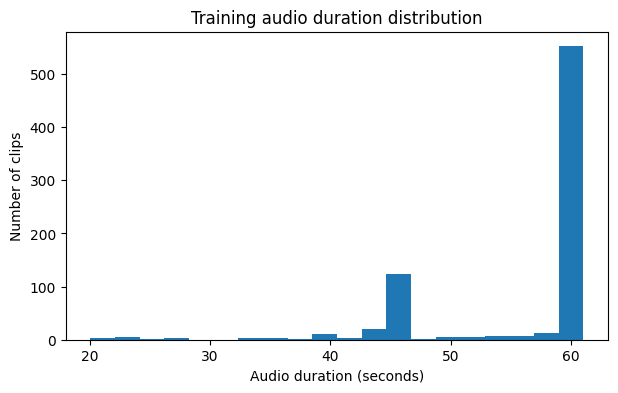

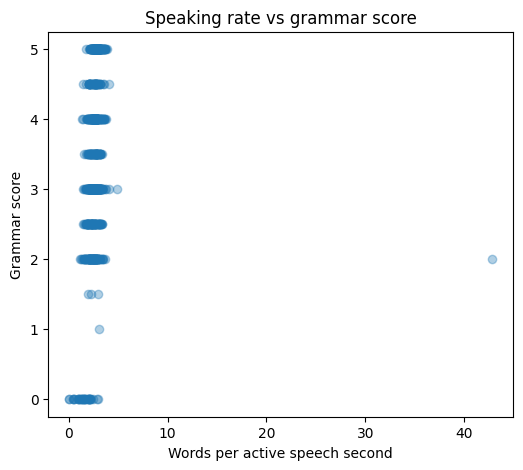

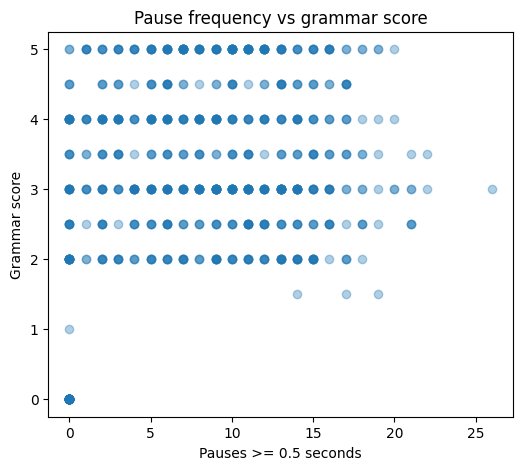

In [14]:
# Useful audio visualizations
plt.figure(figsize=(7, 4))
plt.hist(audio_train["a_duration"], bins=20)
plt.xlabel("Audio duration (seconds)")
plt.ylabel("Number of clips")
plt.title("Training audio duration distribution")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(audio_train["a_words_per_speech_second"], y, alpha=0.35)
plt.xlabel("Words per active speech second")
plt.ylabel("Grammar score")
plt.title("Speaking rate vs grammar score")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(audio_train["a_pause_05_count"], y, alpha=0.35)
plt.xlabel("Pauses >= 0.5 seconds")
plt.ylabel("Grammar score")
plt.title("Pause frequency vs grammar score")
plt.show()

## 7. Build the main feature blocks

The main text block is:

`basic + LanguageTool + GPT-2 + CoLA`

The main hand-made block is:

`text + audio + Whisper timing`

In [15]:
text_train_df = pd.concat([
    basic_train.reset_index(drop=True),
    languagetool_train.reset_index(drop=True),
    gpt2_train.reset_index(drop=True),
    cola_train.reset_index(drop=True),
], axis=1)

text_test_df = pd.concat([
    basic_test.reset_index(drop=True),
    languagetool_test.reset_index(drop=True),
    gpt2_test.reset_index(drop=True),
    cola_test.reset_index(drop=True),
], axis=1)

audio_feature_cols = [c for c in audio_plus_whisper_train.columns if c != ID_COL]
text_feature_cols = list(text_train_df.columns)

all_hand_train = pd.concat([text_train_df, audio_plus_whisper_train[audio_feature_cols]], axis=1)
all_hand_test = pd.concat([text_test_df, audio_plus_whisper_test[audio_feature_cols]], axis=1)

train_medians = all_hand_train.median(numeric_only=True)
all_hand_train = all_hand_train.fillna(train_medians)
all_hand_test = all_hand_test.fillna(train_medians)

TEXT_X_train = all_hand_train[text_feature_cols].to_numpy(dtype=float)
TEXT_X_test = all_hand_test[text_feature_cols].to_numpy(dtype=float)
HAND_X_train = all_hand_train.to_numpy(dtype=float)
HAND_X_test = all_hand_test.to_numpy(dtype=float)

if minilm_train is not None:
    TEXT_MINILM_X_train = np.hstack([HAND_X_train, minilm_train])
    TEXT_MINILM_X_test = np.hstack([HAND_X_test, minilm_test])
else:
    TEXT_MINILM_X_train = TEXT_MINILM_X_test = None

print("Text features:", TEXT_X_train.shape)
print("Text + audio features:", HAND_X_train.shape)

Text features: (769, 20)
Text + audio features: (769, 79)


## 8. Cross-validation helpers and small regressors

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def oof_predictions(make_model, X, target=y, folds=kf, clip=True):
    X = np.asarray(X)
    target = np.asarray(target, dtype=float)
    oof = np.zeros(len(target), dtype=float)

    for train_idx, valid_idx in folds.split(X):
        model = make_model()
        model.fit(X[train_idx], target[train_idx])
        oof[valid_idx] = model.predict(X[valid_idx])

    return np.clip(oof, 0, 5) if clip else oof


def tabular_lgbm():
    return LGBMRegressor(
        n_estimators=350,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=5,
        min_child_samples=20,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=SEED,
        verbosity=-1,
    )


def tabular_svr():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale")),
    ])


def tabular_ridge():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=[1, 10, 30, 100, 300, 1000])),
    ])


def extra_trees():
    return ExtraTreesRegressor(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        max_features=0.8,
        random_state=SEED,
        n_jobs=-1,
    )

## 9. Baseline model comparison

  features      model   rmse  pearson
text+audio   LightGBM 0.6320   0.8600
text+audio        SVR 0.6337   0.8596
text+audio      Ridge 0.6436   0.8551
text+audio ExtraTrees 0.6660   0.8450
      text ExtraTrees 0.9693   0.6238
      text   LightGBM 0.9795   0.6156
      text      Ridge 0.9927   0.5977
      text        SVR 1.0154   0.5961


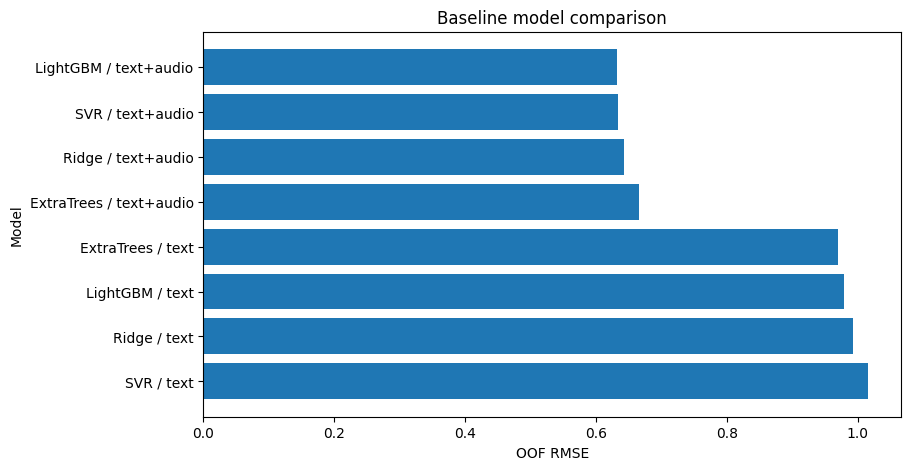

In [17]:
feature_sets = {
    "text": TEXT_X_train,
    "text+audio": HAND_X_train,
}

if TEXT_MINILM_X_train is not None:
    feature_sets["text+audio+MiniLM"] = TEXT_MINILM_X_train

model_makers = {
    "LightGBM": tabular_lgbm,
    "SVR": tabular_svr,
    "Ridge": tabular_ridge,
    "ExtraTrees": extra_trees,
}

base_oof = {}
rows = []

for feature_name, X in feature_sets.items():
    for model_name, maker in model_makers.items():
        pred = oof_predictions(maker, X)
        base_oof[(feature_name, model_name)] = pred
        rows.append({
            "features": feature_name,
            "model": model_name,
            "rmse": rmse(y, pred),
            "pearson": pearson(y, pred),
        })

base_results = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
print(base_results.round(4).to_string(index=False))

plt.figure(figsize=(9, 5))
plot_df = base_results.sort_values("rmse", ascending=True)
plt.barh(plot_df["model"] + " / " + plot_df["features"], plot_df["rmse"])
plt.xlabel("OOF RMSE")
plt.ylabel("Model")
plt.title("Baseline model comparison")
plt.gca().invert_yaxis()
plt.show()

TABULAR_LGBM_OOF = base_oof[("text+audio", "LightGBM")]
TABULAR_SVR_OOF = base_oof[("text+audio", "SVR")]
TABULAR_RIDGE_OOF = base_oof[("text+audio", "Ridge")]
TABULAR_ET_OOF = base_oof[("text+audio", "ExtraTrees")]

## 10. WavLM speech embeddings

WavLM is a frozen speech model. I use middle layers 7–10 because that worked much better in the previous run.

In [55]:
from transformers import AutoFeatureExtractor, AutoModel

wavlm_extractor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
wavlm_model = AutoModel.from_pretrained("microsoft/wavlm-base-plus").to(DEVICE).eval()

@torch.no_grad()
def wavlm_hidden_states(path):
    signal, _ = librosa.load(path, sr=16000, mono=True)
    encoded = wavlm_extractor(signal, sampling_rate=16000, return_tensors="pt")
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    hidden = wavlm_model(**encoded, output_hidden_states=True).hidden_states
    return np.stack([h.mean(dim=1).squeeze(0).cpu().numpy() for h in hidden])


def build_wavlm_cache(frame, audio_dir, name):
    p = CACHE_DIR / f"{name}.npy"
    if p.exists():
        return np.load(p)
    arr = np.stack([
        wavlm_hidden_states(audio_dir / f)
        for f in tqdm(frame[ID_COL], desc=name)
    ])
    np.save(p, arr)
    return arr

WAVLM_TRAIN_LAYERS = build_wavlm_cache(train_df, AUDIO_TRAIN, "wavlm_train")
WAVLM_TEST_LAYERS = build_wavlm_cache(test_df, AUDIO_TEST, "wavlm_test")

WAVLM_MEAN_TRAIN = WAVLM_TRAIN_LAYERS[:, 7:11, :].mean(axis=1)
WAVLM_MEAN_TEST = WAVLM_TEST_LAYERS[:, 7:11, :].mean(axis=1)

WAVLM_STATS_TRAIN = np.hstack([
    WAVLM_TRAIN_LAYERS[:, 7:11, :].mean(axis=1),
    WAVLM_TRAIN_LAYERS[:, 7:11, :].std(axis=1),
])
WAVLM_STATS_TEST = np.hstack([
    WAVLM_TEST_LAYERS[:, 7:11, :].mean(axis=1),
    WAVLM_TEST_LAYERS[:, 7:11, :].std(axis=1),
])

del wavlm_model, wavlm_extractor
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print("WavLM mean shape:", WAVLM_MEAN_TRAIN.shape)

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

WavLM mean shape: (769, 768)


In [19]:
def wavlm_ridge_mean():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=[10, 30, 100, 300, 1000, 3000])),
    ])


def wavlm_ridge_pca():
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=96, svd_solver="randomized", random_state=SEED)),
        ("model", RidgeCV(alphas=[10, 30, 100, 300, 1000])),
    ])

wavlm_oof_mean = oof_predictions(wavlm_ridge_mean, WAVLM_MEAN_TRAIN)
wavlm_oof_stats = oof_predictions(wavlm_ridge_pca, WAVLM_STATS_TRAIN)

describe_result("WavLM mean", y, wavlm_oof_mean)
describe_result("WavLM mean+std PCA", y, wavlm_oof_stats)

WavLM mean: RMSE=0.5816 | Pearson=0.8830
WavLM mean+std PCA: RMSE=0.5892 | Pearson=0.8802


## 11. New experiment — test-like duration weighting

The test set has a different mix of short/long recordings than the train set. I give slightly more weight to training clips from the duration group that is more common in test.

I only apply this idea to Ridge on WavLM, where sample weights are straightforward.

In [20]:
train_duration = audio_train["a_duration"].to_numpy(dtype=float)
test_duration = audio_test["a_duration"].to_numpy(dtype=float)

# Most clips fall around 45 s or 60 s. 52.5 separates the two groups.
train_short = train_duration < 52.5
test_short = test_duration < 52.5

train_short_frac = train_short.mean()
test_short_frac = test_short.mean()
train_long_frac = 1 - train_short_frac
test_long_frac = 1 - test_short_frac

w_short = test_short_frac / max(train_short_frac, 1e-6)
w_long = test_long_frac / max(train_long_frac, 1e-6)
example_weights = np.where(train_short, w_short, w_long)
example_weights = example_weights / example_weights.mean()

print("Train short/long mix:", round(train_short_frac, 3), round(train_long_frac, 3))
print("Test short/long mix :", round(test_short_frac, 3), round(test_long_frac, 3))
print("Weight range:", example_weights.min(), "to", example_weights.max())


def weighted_wavlm_ridge_oof(X, weights, alpha=100.0):
    pred = np.zeros(len(y), dtype=float)
    for tr, va in kf.split(X):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xva = scaler.transform(X[va])
        model = Ridge(alpha=alpha)
        model.fit(Xtr, y[tr], sample_weight=weights[tr])
        pred[va] = model.predict(Xva)
    return np.clip(pred, 0, 5)

weighted_wavlm_oof = weighted_wavlm_ridge_oof(WAVLM_MEAN_TRAIN, example_weights, alpha=100.0)
describe_result("Weighted WavLM Ridge", y, weighted_wavlm_oof)

Train short/long mix: 0.246 0.754
Test short/long mix : 0.694 0.306
Weight range: 0.405124521072797 to 2.8255437977660205
Weighted WavLM Ridge: RMSE=0.6114 | Pearson=0.8700


## 12. New experiment — Whisper encoder embeddings

Whisper already creates the transcript. Here I also use its frozen encoder representation as a second speech view.

Each clip is split into up-to-30-second chunks. For each chunk I average the encoder frames, then combine chunk vectors. I test all encoder layers first, then keep the strongest representation.

In [21]:
from transformers import WhisperFeatureExtractor, WhisperModel

whisper_enc_name = "openai/whisper-small"
wfe = WhisperFeatureExtractor.from_pretrained(whisper_enc_name)
wenc = WhisperModel.from_pretrained(whisper_enc_name).encoder.to(DEVICE).eval()

@torch.no_grad()
def whisper_encoder_layers(path):
    signal, _ = librosa.load(path, sr=16000, mono=True)
    chunk_size = 480000  # 30 seconds at 16 kHz
    chunks = [signal[i:i + chunk_size] for i in range(0, len(signal), chunk_size)]
    chunks = [c for c in chunks if len(c) >= 16000] or [signal]

    chunk_outputs = []
    chunk_weights = []

    for c in chunks:
        feats = wfe(c, sampling_rate=16000, return_tensors="pt").input_features.to(DEVICE)
        hidden_states = wenc(feats, output_hidden_states=True).hidden_states

        # Whisper encoder is about 50 frames/sec after the convolutional downsampling.
        valid_frames = min(hidden_states[0].shape[1], max(1, int(np.ceil(len(c) / 320))))

        pooled = np.stack([
            h[0, :valid_frames].mean(dim=0).cpu().numpy()
            for h in hidden_states
        ])
        chunk_outputs.append(pooled)
        chunk_weights.append(valid_frames)

    return np.average(np.stack(chunk_outputs), axis=0, weights=np.asarray(chunk_weights))


def build_whisper_encoder_cache(frame, audio_dir, name):
    p = CACHE_DIR / f"{name}.npy"
    if p.exists():
        return np.load(p)
    arr = np.stack([
        whisper_encoder_layers(audio_dir / f)
        for f in tqdm(frame[ID_COL], desc=name)
    ])
    np.save(p, arr)
    return arr

WENC_TRAIN = build_whisper_encoder_cache(train_df, AUDIO_TRAIN, "whisper_encoder_train")
WENC_TEST = build_whisper_encoder_cache(test_df, AUDIO_TEST, "whisper_encoder_test")

print("Whisper encoder cache:", WENC_TRAIN.shape)

del wenc, wfe
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

whisper_encoder_train:   0%|          | 0/769 [00:00<?, ?it/s]

whisper_encoder_test:   0%|          | 0/216 [00:00<?, ?it/s]

Whisper encoder cache: (769, 13, 768)


 layer   rmse  pearson
    10 0.5787   0.8845
     8 0.5799   0.8840
     7 0.5847   0.8820
    12 0.5849   0.8827
     9 0.5850   0.8816
     6 0.5956   0.8775
    11 0.5973   0.8766
     5 0.6298   0.8611
     3 0.6560   0.8482
     4 0.6563   0.8480
     2 0.7002   0.8250
     1 0.7080   0.8205
     0 0.7798   0.7776


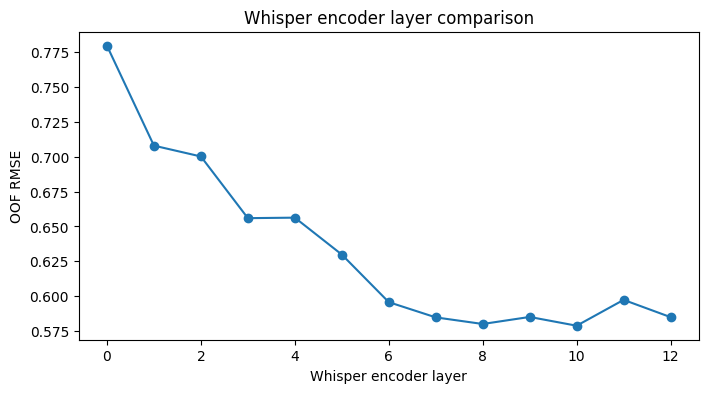

Best Whisper encoder layer 10: RMSE=0.5787 | Pearson=0.8845


In [22]:
# Compare layers with a simple Ridge model.
whisper_layer_rows = []
whisper_layer_oof = {}

for layer in range(WENC_TRAIN.shape[1]):
    pred = oof_predictions(wavlm_ridge_mean, WENC_TRAIN[:, layer, :])
    whisper_layer_oof[layer] = pred
    whisper_layer_rows.append({
        "layer": layer,
        "rmse": rmse(y, pred),
        "pearson": pearson(y, pred),
    })

whisper_layer_results = pd.DataFrame(whisper_layer_rows).sort_values("rmse").reset_index(drop=True)
print(whisper_layer_results.round(4).to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(whisper_layer_results.sort_values("layer")["layer"], whisper_layer_results.sort_values("layer")["rmse"], marker="o")
plt.xlabel("Whisper encoder layer")
plt.ylabel("OOF RMSE")
plt.title("Whisper encoder layer comparison")
plt.show()

BEST_WHISPER_LAYER = int(whisper_layer_results.iloc[0]["layer"])
WHISPER_BEST_OOF = whisper_layer_oof[BEST_WHISPER_LAYER]
WHISPER_BEST_TRAIN = WENC_TRAIN[:, BEST_WHISPER_LAYER, :]
WHISPER_BEST_TEST = WENC_TEST[:, BEST_WHISPER_LAYER, :]

describe_result(f"Best Whisper encoder layer {BEST_WHISPER_LAYER}", y, WHISPER_BEST_OOF)

## 13. Combine the two speech views

This is the main new experiment. WavLM and Whisper were trained for different purposes, so their embeddings can contain different information about fluency and delivery.

In [23]:
COMBINED_SPEECH_TRAIN = np.hstack([WAVLM_MEAN_TRAIN, WHISPER_BEST_TRAIN])
COMBINED_SPEECH_TEST = np.hstack([WAVLM_MEAN_TEST, WHISPER_BEST_TEST])

combined_speech_oof = oof_predictions(wavlm_ridge_mean, COMBINED_SPEECH_TRAIN)

describe_result("Combined WavLM + Whisper Ridge", y, combined_speech_oof)

Combined WavLM + Whisper Ridge: RMSE=0.5633 | Pearson=0.8909


## 14. Zero-score aware model

The train set has some score-0 clips. I keep this as an experiment, but I do not force it into the final model unless OOF RMSE improves.

In [24]:
zero_features = np.hstack([HAND_X_train, TEXT_X_train[:, :len(basic_train.columns)]])
zero_target = (y == 0).astype(int)
nonzero_mask = y > 0


def zero_classifier():
    return LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        num_leaves=7,
        max_depth=4,
        min_child_samples=15,
        reg_lambda=2.0,
        random_state=SEED,
        verbosity=-1,
    )


def zero_aware_oof(alpha=1.0):
    pred = np.zeros(len(y), dtype=float)
    for tr, va in kf.split(zero_features):
        clf = zero_classifier()
        reg = tabular_lgbm()
        clf.fit(zero_features[tr], zero_target[tr])
        nz_tr = tr[y[tr] > 0]
        reg.fit(HAND_X_train[nz_tr], y[nz_tr])
        p_zero = clf.predict_proba(zero_features[va])[:, 1]
        nz_score = np.clip(reg.predict(HAND_X_train[va]), 0, 5)
        pred[va] = np.power(np.clip(1 - p_zero, 0, 1), alpha) * nz_score
    return np.clip(pred, 0, 5)

zero_rows = []
for alpha in [0.5, 0.75, 1.0, 1.25, 1.5]:
    pred = zero_aware_oof(alpha)
    zero_rows.append({
        "alpha": alpha,
        "rmse": rmse(y, pred),
        "pearson": pearson(y, pred),
    })

zero_results = pd.DataFrame(zero_rows).sort_values("rmse")
BEST_ZERO_ALPHA = float(zero_results.iloc[0]["alpha"])
ZERO_AWARE_OOF = zero_aware_oof(BEST_ZERO_ALPHA)
print(zero_results.round(4).to_string(index=False))

 alpha   rmse  pearson
  1.50 0.6294   0.8615
  1.25 0.6295   0.8615
  1.00 0.6301   0.8614
  0.75 0.6328   0.8610
  0.50 0.6442   0.8581


## 15. Ordinal model

The labels are in 0.5 steps. I therefore also try a threshold model: for each 0.5 threshold, predict whether the score is at least that threshold.

In [25]:
ORDINAL_THRESHOLDS = np.arange(0.5, 5.01, 0.5)


def ordinal_classifier():
    return LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        num_leaves=7,
        max_depth=4,
        min_child_samples=20,
        reg_lambda=2.0,
        random_state=SEED,
        verbosity=-1,
    )


def probabilities_to_expected_score(probabilities):
    probabilities = np.minimum.accumulate(probabilities, axis=1)
    return np.clip(0.5 * probabilities.sum(axis=1), 0, 5)


def ordinal_oof_predictions(X):
    out = np.zeros((len(y), len(ORDINAL_THRESHOLDS)), dtype=float)
    for tr, va in kf.split(X):
        for j, threshold in enumerate(ORDINAL_THRESHOLDS):
            model = ordinal_classifier()
            model.fit(X[tr], (y[tr] >= threshold).astype(int))
            out[va, j] = model.predict_proba(X[va])[:, 1]
    return probabilities_to_expected_score(out)

ORDINAL_OOF = ordinal_oof_predictions(HAND_X_train)
describe_result("Ordinal model", y, ORDINAL_OOF)

Ordinal model: RMSE=0.6505 | Pearson=0.8549


## 16. Compare strong candidates

     candidate   rmse  pearson
 wavlm_whisper 0.5633   0.8909
  whisper_best 0.5787   0.8845
    wavlm_mean 0.5816   0.8830
     wavlm_pca 0.5892   0.8802
weighted_wavlm 0.6114   0.8700
    zero_aware 0.6294   0.8615
  tabular_lgbm 0.6320   0.8600
   tabular_svr 0.6337   0.8596
       ordinal 0.6505   0.8549


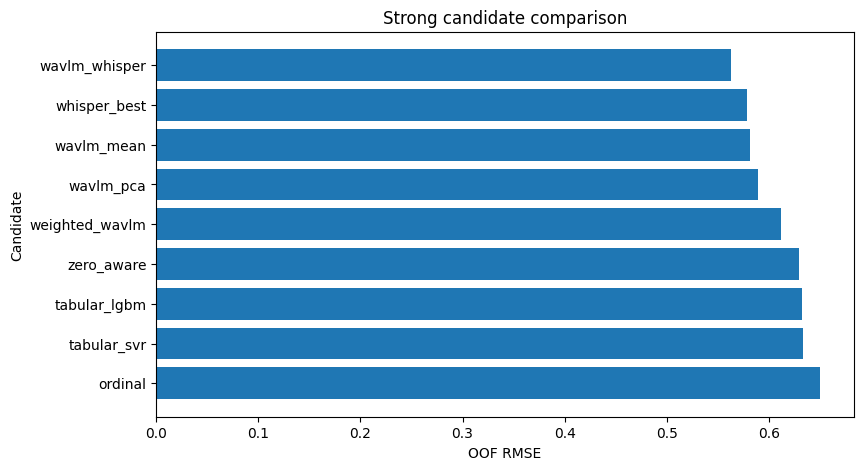

In [26]:
candidates = {
    "tabular_lgbm": TABULAR_LGBM_OOF,
    "tabular_svr": TABULAR_SVR_OOF,
    "wavlm_mean": wavlm_oof_mean,
    "wavlm_pca": wavlm_oof_stats,
    "weighted_wavlm": weighted_wavlm_oof,
    "whisper_best": WHISPER_BEST_OOF,
    "wavlm_whisper": combined_speech_oof,
    "zero_aware": ZERO_AWARE_OOF,
    "ordinal": ORDINAL_OOF,
}

candidate_rows = [
    {"candidate": name, "rmse": rmse(y, pred), "pearson": pearson(y, pred)}
    for name, pred in candidates.items()
]

candidate_results = pd.DataFrame(candidate_rows).sort_values("rmse").reset_index(drop=True)
print(candidate_results.round(4).to_string(index=False))

plt.figure(figsize=(9, 5))
plot_df = candidate_results.sort_values("rmse")
plt.barh(plot_df["candidate"], plot_df["rmse"])
plt.xlabel("OOF RMSE")
plt.ylabel("Candidate")
plt.title("Strong candidate comparison")
plt.gca().invert_yaxis()
plt.show()

## 17. New experiment — Whisper word timing and speech fluency

The transcript tells me **what** was said. Word timestamps tell me more about **how** it was said.

I extract speaking rate, articulation rate, pause sizes, word duration, and Whisper word confidence. These are useful because this is a spoken-language task, not a written grammar task.

Whisper word timing train:   0%|          | 0/769 [00:00<?, ?it/s]

Whisper word timing test:   0%|          | 0/216 [00:00<?, ?it/s]

                        count     mean     std   min      25%      50%  \
wt_word_count           769.0   99.984  26.827  0.00   81.000  100.000   
wt_wpm                  769.0  108.290  26.800  0.00   90.887  110.683   
wt_articulation_wpm     769.0  118.283  27.006  0.00  101.412  119.945   
wt_mean_word_sec        769.0    0.468   0.119  0.00    0.388    0.443   
wt_std_word_sec         769.0    0.392   0.192  0.00    0.271    0.346   
wt_pause_mean           769.0    0.070   0.083  0.00    0.029    0.052   
wt_pause_std            769.0    0.305   0.418  0.00    0.145    0.222   
wt_pause_p90            769.0    0.087   0.177  0.00    0.000    0.000   
wt_pause_max            769.0    2.192   2.995  0.00    0.920    1.420   
wt_long_pause_fraction  769.0    0.046   0.031  0.00    0.023    0.041   
wt_word_prob_mean       769.0    0.860   0.087  0.00    0.828    0.881   
wt_word_prob_std        769.0    0.188   0.049  0.00    0.152    0.185   
wt_first_speech_delay   769.0    2.848

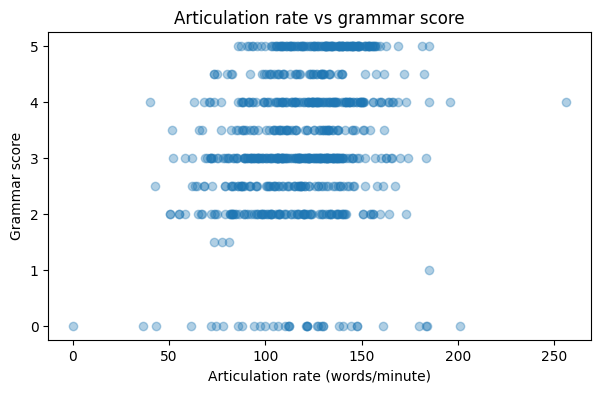

In [27]:
from faster_whisper import WhisperModel

WORD_TIMING_CACHE_TRAIN = CACHE_DIR / "whisper_word_timing_train.csv"
WORD_TIMING_CACHE_TEST = CACHE_DIR / "whisper_word_timing_test.csv"

_word_model = None

def get_word_model():
    global _word_model
    if _word_model is None:
        if DEVICE == "cuda":
            _word_model = WhisperModel(
                "small",
                device="cuda",
                compute_type="float16"
            )
        else:
            _word_model = WhisperModel(
                "small",
                device="cpu",
                compute_type="int8"
            )
    return _word_model

def word_timing_features(path):
    signal, sr = librosa.load(path, sr=16000, mono=True)

    segments, _ = get_word_model().transcribe(
        signal.astype(np.float32),
        language="en",
        beam_size=5,
        condition_on_previous_text=False,
        word_timestamps=True,
    )
    segments = list(segments)

    words = []
    segment_count = len(segments)

    for seg in segments:
        if seg.words is None:
            continue

        for w in seg.words:
            if w.start is None or w.end is None:
                continue

            words.append({
                "start": float(w.start),
                "end": float(w.end),
                "prob": float(getattr(w, "probability", np.nan)),
            })

    duration = len(signal) / sr

    if not words:
        return {
            "wt_word_count": 0.0,
            "wt_wpm": 0.0,
            "wt_articulation_wpm": 0.0,
            "wt_mean_word_sec": 0.0,
            "wt_std_word_sec": 0.0,
            "wt_pause_mean": 0.0,
            "wt_pause_std": 0.0,
            "wt_pause_p90": 0.0,
            "wt_pause_max": 0.0,
            "wt_long_pause_fraction": 0.0,
            "wt_word_prob_mean": 0.0,
            "wt_word_prob_std": 0.0,
            "wt_first_speech_delay": duration,
            "wt_trailing_silence": duration,
            "wt_segment_count": float(segment_count),
        }

    starts = np.array([w["start"] for w in words], dtype=float)
    ends = np.array([w["end"] for w in words], dtype=float)
    probs = np.array([w["prob"] for w in words], dtype=float)

    word_duration = np.maximum(ends - starts, 1e-3)
    gaps = starts[1:] - ends[:-1] if len(words) > 1 else np.array([])
    gaps = gaps[gaps >= 0]
    speech_span = max(ends[-1] - starts[0], 1e-3)

    long_pause_fraction = (
        float((gaps >= 0.5).mean()) if len(gaps) else 0.0
    )

    probs = probs[np.isfinite(probs)]

    return {
        "wt_word_count": float(len(words)),
        "wt_wpm": float(len(words) / max(duration, 1e-3) * 60.0),
        "wt_articulation_wpm": float(len(words) / speech_span * 60.0),
        "wt_mean_word_sec": float(word_duration.mean()),
        "wt_std_word_sec": float(word_duration.std()),
        "wt_pause_mean": float(gaps.mean()) if len(gaps) else 0.0,
        "wt_pause_std": float(gaps.std()) if len(gaps) else 0.0,
        "wt_pause_p90": float(np.percentile(gaps, 90)) if len(gaps) else 0.0,
        "wt_pause_max": float(gaps.max()) if len(gaps) else 0.0,
        "wt_long_pause_fraction": long_pause_fraction,
        "wt_word_prob_mean": float(probs.mean()) if len(probs) else 0.0,
        "wt_word_prob_std": float(probs.std()) if len(probs) else 0.0,
        "wt_first_speech_delay": float(starts[0]),
        "wt_trailing_silence": float(max(duration - ends[-1], 0.0)),
        "wt_segment_count": float(segment_count),
    }

def build_word_timing_table(frame, audio_dir, cache_path, name):
    if cache_path.exists():
        return pd.read_csv(cache_path)

    rows = []
    for filename in tqdm(frame[ID_COL], desc=name):
        rows.append(word_timing_features(audio_dir / filename))

    table = pd.DataFrame(rows)
    table.to_csv(cache_path, index=False)
    return table

word_timing_train = build_word_timing_table(
    train_df, AUDIO_TRAIN, WORD_TIMING_CACHE_TRAIN, "Whisper word timing train"
)
word_timing_test = build_word_timing_table(
    test_df, AUDIO_TEST, WORD_TIMING_CACHE_TEST, "Whisper word timing test"
)

print(word_timing_train.describe().T.round(3))

del _word_model
_word_model = None
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

plt.figure(figsize=(7, 4))
plt.scatter(
    word_timing_train["wt_articulation_wpm"],
    y,
    alpha=0.35
)
plt.xlabel("Articulation rate (words/minute)")
plt.ylabel("Grammar score")
plt.title("Articulation rate vs grammar score")
plt.show()


## 18. New experiment — GPT-2 token surprisal

Perplexity gives one number for the whole response. Here I also keep simple statistics of the token-level surprisal:

- mean surprise
- variation in surprise
- high-surprise fraction
- upper-tail surprise

This can detect awkward local word sequences that get hidden by one global perplexity score.

In [28]:
from transformers import AutoTokenizer, AutoModelForCausalLM

SURPRISE_TRAIN_CACHE = CACHE_DIR / "gpt2_surprisal_train.csv"
SURPRISE_TEST_CACHE = CACHE_DIR / "gpt2_surprisal_test.csv"

surprise_tokenizer = AutoTokenizer.from_pretrained("gpt2")
surprise_model = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()

@torch.no_grad()
def gpt2_surprisal_features(text):
    text = str(text).strip()

    if not text:
        return {
            "gpt2_nll_mean": 0.0,
            "gpt2_nll_std": 0.0,
            "gpt2_nll_p90": 0.0,
            "gpt2_nll_max": 0.0,
            "gpt2_high_surprise_fraction": 0.0,
        }

    encoded = surprise_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    outputs = surprise_model(**encoded)
    logits = outputs.logits[:, :-1, :]
    labels = encoded["input_ids"][:, 1:]
    mask = encoded["attention_mask"][:, 1:].bool()

    log_probs = torch.log_softmax(logits, dim=-1)
    token_nll = -log_probs.gather(
        2,
        labels.unsqueeze(-1)
    ).squeeze(-1)

    values = token_nll[mask].detach().float().cpu().numpy()

    if len(values) == 0:
        return {
            "gpt2_nll_mean": 0.0,
            "gpt2_nll_std": 0.0,
            "gpt2_nll_p90": 0.0,
            "gpt2_nll_max": 0.0,
            "gpt2_high_surprise_fraction": 0.0,
        }

    return {
        "gpt2_nll_mean": float(values.mean()),
        "gpt2_nll_std": float(values.std()),
        "gpt2_nll_p90": float(np.percentile(values, 90)),
        "gpt2_nll_max": float(np.percentile(values, 99)),
        "gpt2_high_surprise_fraction": float((values > 3.0).mean()),
    }

def build_surprise_table(texts, cache_path, name):
    if cache_path.exists():
        return pd.read_csv(cache_path)

    table = pd.DataFrame([
        gpt2_surprisal_features(t)
        for t in tqdm(texts, desc=name)
    ])
    table.to_csv(cache_path, index=False)
    return table

gpt2_surprise_train = build_surprise_table(
    train_texts, SURPRISE_TRAIN_CACHE, "GPT-2 token surprisal train"
)
gpt2_surprise_test = build_surprise_table(
    test_texts, SURPRISE_TEST_CACHE, "GPT-2 token surprisal test"
)

print(gpt2_surprise_train.describe().T.round(3))

del surprise_model, surprise_tokenizer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 token surprisal train:   0%|          | 0/769 [00:00<?, ?it/s]

GPT-2 token surprisal test:   0%|          | 0/216 [00:00<?, ?it/s]

                             count    mean    std    min     25%     50%  \
gpt2_nll_mean                769.0   3.639  0.523  2.358   3.256   3.604   
gpt2_nll_std                 769.0   2.766  0.340  1.246   2.534   2.757   
gpt2_nll_p90                 769.0   7.453  1.013  3.921   6.736   7.407   
gpt2_nll_max                 769.0  11.270  1.535  3.993  10.278  11.143   
gpt2_high_surprise_fraction  769.0   0.501  0.077  0.284   0.447   0.500   

                                75%     max  
gpt2_nll_mean                 3.940   5.881  
gpt2_nll_std                  2.956   4.473  
gpt2_nll_p90                  8.064  11.117  
gpt2_nll_max                 12.173  17.131  
gpt2_high_surprise_fraction   0.553   0.755  


## 19. Build the improved tabular feature block

The original hand-made feature block is kept. I only add the new word-timing and token-surprisal features.

In [29]:
enhanced_train_df = pd.concat(
    [
        all_hand_train.reset_index(drop=True),
        word_timing_train.reset_index(drop=True),
        gpt2_surprise_train.reset_index(drop=True),
    ],
    axis=1,
)

enhanced_test_df = pd.concat(
    [
        all_hand_test.reset_index(drop=True),
        word_timing_test.reset_index(drop=True),
        gpt2_surprise_test.reset_index(drop=True),
    ],
    axis=1,
)

enhanced_medians = enhanced_train_df.median(numeric_only=True)

enhanced_train_df = enhanced_train_df.fillna(enhanced_medians)
enhanced_test_df = enhanced_test_df.fillna(enhanced_medians)

ENHANCED_HAND_X_train = enhanced_train_df.to_numpy(dtype=float)
ENHANCED_HAND_X_test = enhanced_test_df.to_numpy(dtype=float)

print("Old tabular features :", HAND_X_train.shape[1])
print("New tabular features :", ENHANCED_HAND_X_train.shape[1])


Old tabular features : 79
New tabular features : 99


## 20. Stronger regressors on speech embeddings

Ridge is good at using a large frozen embedding, but it only learns a linear relationship.

I also test:
- RBF-SVR after PCA
- distance-weighted KNN after PCA

Both are small models and still easy to explain.

WavLM RBF-SVR: RMSE=0.5508 | Pearson=0.8957
WavLM KNN: RMSE=0.6654 | Pearson=0.8450
WavLM + Whisper RBF-SVR: RMSE=0.5253 | Pearson=0.9058


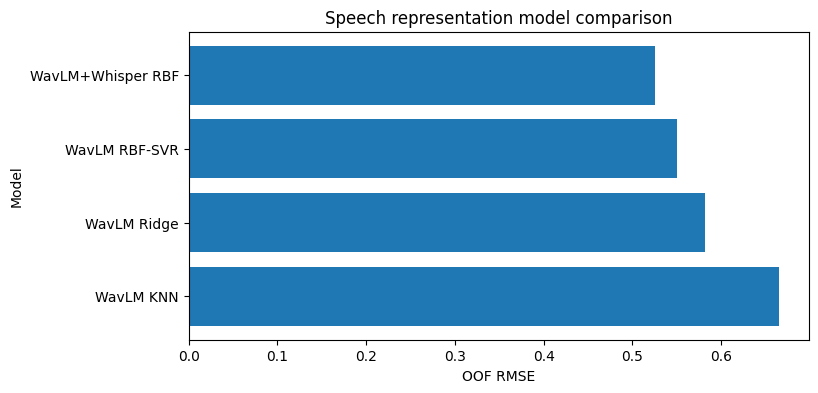

In [30]:
from sklearn.neighbors import KNeighborsRegressor

def wavlm_rbf_svr():
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(
            n_components=96,
            svd_solver="randomized",
            random_state=SEED,
        )),
        ("model", SVR(
            kernel="rbf",
            C=10,
            epsilon=0.05,
            gamma="scale",
        )),
    ])

def wavlm_knn():
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(
            n_components=64,
            svd_solver="randomized",
            random_state=SEED,
        )),
        ("model", KNeighborsRegressor(
            n_neighbors=15,
            weights="distance",
            p=2,
            n_jobs=-1,
        )),
    ])

def speech_rbf_svr():
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(
            n_components=128,
            svd_solver="randomized",
            random_state=SEED,
        )),
        ("model", SVR(
            kernel="rbf",
            C=10,
            epsilon=0.05,
            gamma="scale",
        )),
    ])

WAVLM_RBF_OOF = oof_predictions(
    wavlm_rbf_svr,
    WAVLM_MEAN_TRAIN,
)

WAVLM_KNN_OOF = oof_predictions(
    wavlm_knn,
    WAVLM_MEAN_TRAIN,
)

COMBINED_RBF_OOF = oof_predictions(
    speech_rbf_svr,
    COMBINED_SPEECH_TRAIN,
)

describe_result("WavLM RBF-SVR", y, WAVLM_RBF_OOF)
describe_result("WavLM KNN", y, WAVLM_KNN_OOF)
describe_result("WavLM + Whisper RBF-SVR", y, COMBINED_RBF_OOF)

plt.figure(figsize=(8, 4))
new_speech_rows = pd.DataFrame({
    "model": [
        "WavLM Ridge",
        "WavLM RBF-SVR",
        "WavLM KNN",
        "WavLM+Whisper RBF",
    ],
    "rmse": [
        rmse(y, wavlm_oof_mean),
        rmse(y, WAVLM_RBF_OOF),
        rmse(y, WAVLM_KNN_OOF),
        rmse(y, COMBINED_RBF_OOF),
    ]
}).sort_values("rmse")

plt.barh(new_speech_rows["model"], new_speech_rows["rmse"])
plt.xlabel("OOF RMSE")
plt.ylabel("Model")
plt.title("Speech representation model comparison")
plt.gca().invert_yaxis()
plt.show()


## 21. New speech view — HuBERT

WavLM and Whisper are already strong. HuBERT is another frozen self-supervised speech representation, so I use it only as a diversity experiment.

The notebook automatically checks all HuBERT encoder layers and keeps the best one by OOF RMSE.

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT train:   0%|          | 0/769 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

HuBERT test:   0%|          | 0/216 [00:00<?, ?it/s]

HuBERT cache shape: (769, 13, 768)
 layer   rmse  pearson
     8 0.5980   0.8759
    10 0.5983   0.8758
     7 0.5996   0.8754
     9 0.6100   0.8704
     6 0.6104   0.8701
    11 0.6125   0.8692
     5 0.6311   0.8606
    12 0.6312   0.8603
     4 0.6525   0.8499
     3 0.6714   0.8403
     2 0.7137   0.8183
     1 0.7375   0.8036
     0 0.7675   0.7866


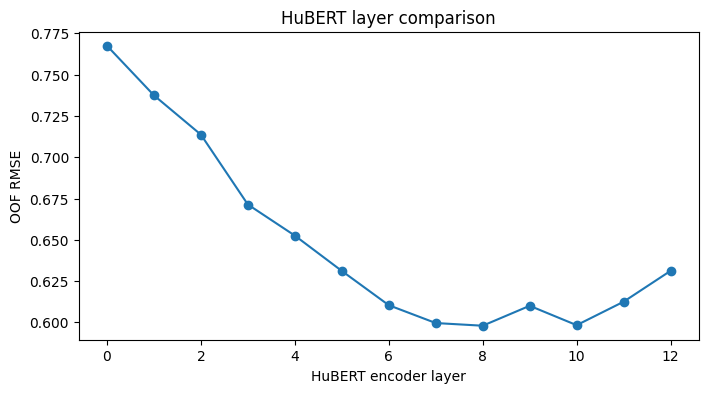

Best HuBERT layer 8: RMSE=0.5980 | Pearson=0.8759


In [31]:
from transformers import AutoFeatureExtractor, AutoModel

HUBERT_CACHE_TRAIN = CACHE_DIR / "hubert_layers_train.npy"
HUBERT_CACHE_TEST = CACHE_DIR / "hubert_layers_test.npy"

hubert_name = "facebook/hubert-base-ls960"
hubert_extractor = AutoFeatureExtractor.from_pretrained(hubert_name)
hubert_model = AutoModel.from_pretrained(hubert_name).to(DEVICE).eval()

@torch.no_grad()
def hubert_hidden_layers(path):
    signal, _ = librosa.load(path, sr=16000, mono=True)

    chunk_size = 320000  # 20 sec
    chunks = [
        signal[i:i + chunk_size]
        for i in range(0, len(signal), chunk_size)
    ]
    chunks = [c for c in chunks if len(c) >= 16000] or [signal]

    pooled_chunks = []
    weights = []

    for chunk in chunks:
        inputs = hubert_extractor(
            chunk.astype(np.float32),
            sampling_rate=16000,
            return_tensors="pt",
            padding=False,
        )
        inputs = {
            k: v.to(DEVICE)
            for k, v in inputs.items()
        }

        hidden_states = hubert_model(
            **inputs,
            output_hidden_states=True,
        ).hidden_states

        pooled = np.stack([
            h[0].mean(dim=0).detach().cpu().numpy()
            for h in hidden_states
        ])

        pooled_chunks.append(pooled)
        weights.append(len(chunk))

    return np.average(
        np.stack(pooled_chunks),
        axis=0,
        weights=np.asarray(weights),
    )

def build_hubert_cache(frame, audio_dir, cache_path, name):
    if cache_path.exists():
        return np.load(cache_path)

    arr = np.stack([
        hubert_hidden_layers(audio_dir / f)
        for f in tqdm(frame[ID_COL], desc=name)
    ])

    np.save(cache_path, arr)
    return arr

HUBERT_TRAIN_LAYERS = build_hubert_cache(
    train_df,
    AUDIO_TRAIN,
    HUBERT_CACHE_TRAIN,
    "HuBERT train",
)

HUBERT_TEST_LAYERS = build_hubert_cache(
    test_df,
    AUDIO_TEST,
    HUBERT_CACHE_TEST,
    "HuBERT test",
)

print("HuBERT cache shape:", HUBERT_TRAIN_LAYERS.shape)

hubert_layer_rows = []
hubert_layer_oof = {}

for layer in range(HUBERT_TRAIN_LAYERS.shape[1]):
    pred = oof_predictions(
        wavlm_ridge_mean,
        HUBERT_TRAIN_LAYERS[:, layer, :]
    )

    hubert_layer_oof[layer] = pred

    hubert_layer_rows.append({
        "layer": layer,
        "rmse": rmse(y, pred),
        "pearson": pearson(y, pred),
    })

hubert_layer_results = (
    pd.DataFrame(hubert_layer_rows)
    .sort_values("rmse")
    .reset_index(drop=True)
)

print(hubert_layer_results.round(4).to_string(index=False))

plt.figure(figsize=(8, 4))
tmp = hubert_layer_results.sort_values("layer")
plt.plot(tmp["layer"], tmp["rmse"], marker="o")
plt.xlabel("HuBERT encoder layer")
plt.ylabel("OOF RMSE")
plt.title("HuBERT layer comparison")
plt.show()

BEST_HUBERT_LAYER = int(hubert_layer_results.iloc[0]["layer"])

HUBERT_BEST_OOF = hubert_layer_oof[BEST_HUBERT_LAYER]
HUBERT_BEST_TRAIN = HUBERT_TRAIN_LAYERS[:, BEST_HUBERT_LAYER, :]
HUBERT_BEST_TEST = HUBERT_TEST_LAYERS[:, BEST_HUBERT_LAYER, :]

describe_result(
    f"Best HuBERT layer {BEST_HUBERT_LAYER}",
    y,
    HUBERT_BEST_OOF,
)

del hubert_model, hubert_extractor
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


## 22. Domain adaptation — make the training set look more like the test set

The test clips are not distributed exactly like the training clips.

I use an unlabeled train-vs-test classifier to estimate which training examples look more like the test distribution. These are used only as training weights.

This uses **no test labels**.

Train-vs-test domain AUC: 0.7943
Domain weight range: 0.286 to 4.571


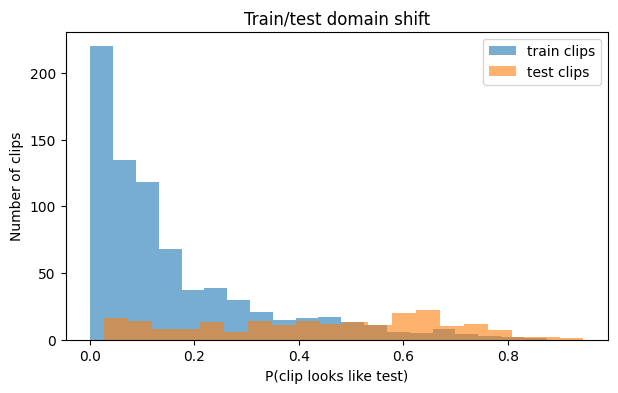

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

domain_train = np.hstack([
    WAVLM_MEAN_TRAIN,
    basic_train.to_numpy(dtype=float),
    audio_train.drop(columns=[ID_COL]).to_numpy(dtype=float),
])

domain_test = np.hstack([
    WAVLM_MEAN_TEST,
    basic_test.to_numpy(dtype=float),
    audio_test.drop(columns=[ID_COL]).to_numpy(dtype=float),
])

domain_X = np.vstack([domain_train, domain_test])
domain_y = np.concatenate([
    np.zeros(len(domain_train), dtype=int),
    np.ones(len(domain_test), dtype=int),
])

domain_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(
        n_components=32,
        svd_solver="randomized",
        random_state=SEED,
    )),
    ("model", LogisticRegression(
        C=0.5,
        max_iter=3000,
        random_state=SEED,
    )),
])

domain_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

domain_oof_prob = np.zeros(len(domain_y))

for tr, va in domain_cv.split(domain_X, domain_y):
    domain_model = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(
            n_components=32,
            svd_solver="randomized",
            random_state=SEED,
        )),
        ("model", LogisticRegression(
            C=0.5,
            max_iter=3000,
            random_state=SEED,
        )),
    ])

    domain_model.fit(domain_X[tr], domain_y[tr])
    domain_oof_prob[va] = domain_model.predict_proba(domain_X[va])[:, 1]

domain_auc = roc_auc_score(domain_y, domain_oof_prob)
print("Train-vs-test domain AUC:", round(domain_auc, 4))

domain_pipeline.fit(domain_X, domain_y)

domain_train_prob = domain_pipeline.predict_proba(domain_train)[:, 1]
domain_test_prob = domain_pipeline.predict_proba(domain_test)[:, 1]

raw_weights = (
    np.clip(domain_train_prob, 1e-4, 1 - 1e-4)
    / np.clip(1 - domain_train_prob, 1e-4, 1)
)
raw_weights *= len(domain_train) / len(domain_test)

domain_weights = np.clip(raw_weights, 0.25, 4.0)
domain_weights /= domain_weights.mean()

print(
    "Domain weight range:",
    round(domain_weights.min(), 3),
    "to",
    round(domain_weights.max(), 3),
)

plt.figure(figsize=(7, 4))
plt.hist(
    domain_train_prob,
    bins=20,
    alpha=0.6,
    label="train clips",
)
plt.hist(
    domain_test_prob,
    bins=20,
    alpha=0.6,
    label="test clips",
)
plt.xlabel("P(clip looks like test)")
plt.ylabel("Number of clips")
plt.title("Train/test domain shift")
plt.legend()
plt.show()


In [33]:
def weighted_enhanced_lgbm_oof(weights):
    pred = np.zeros(len(y), dtype=float)

    for tr, va in kf.split(ENHANCED_HAND_X_train):
        model = tabular_lgbm()
        model.fit(
            ENHANCED_HAND_X_train[tr],
            y[tr],
            sample_weight=weights[tr],
        )
        pred[va] = model.predict(ENHANCED_HAND_X_train[va])

    return np.clip(pred, 0, 5)

DOMAIN_WEIGHTED_LGBM_OOF = weighted_enhanced_lgbm_oof(domain_weights)

def weighted_speech_ridge_oof(X, weights, alpha=100.0):
    pred = np.zeros(len(y), dtype=float)

    for tr, va in kf.split(X):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xva = scaler.transform(X[va])

        model = Ridge(alpha=alpha)
        model.fit(
            Xtr,
            y[tr],
            sample_weight=weights[tr],
        )

        pred[va] = model.predict(Xva)

    return np.clip(pred, 0, 5)

DOMAIN_WEIGHTED_SPEECH_OOF = weighted_speech_ridge_oof(
    COMBINED_SPEECH_TRAIN,
    domain_weights,
    alpha=100.0,
)

describe_result(
    "Domain-weighted enhanced LightGBM",
    y,
    DOMAIN_WEIGHTED_LGBM_OOF,
)

describe_result(
    "Domain-weighted WavLM+Whisper Ridge",
    y,
    DOMAIN_WEIGHTED_SPEECH_OOF,
)


Domain-weighted enhanced LightGBM: RMSE=0.6298 | Pearson=0.8617
Domain-weighted WavLM+Whisper Ridge: RMSE=0.5828 | Pearson=0.8823


## 23. Improved tabular baselines with the new features

In [34]:
ENH_LGBM_OOF = oof_predictions(
    tabular_lgbm,
    ENHANCED_HAND_X_train,
)

ENH_SVR_OOF = oof_predictions(
    tabular_svr,
    ENHANCED_HAND_X_train,
)

describe_result("Enhanced LightGBM", y, ENH_LGBM_OOF)
describe_result("Enhanced SVR", y, ENH_SVR_OOF)


Enhanced LightGBM: RMSE=0.6195 | Pearson=0.8661
Enhanced SVR: RMSE=0.6511 | Pearson=0.8522


In [35]:
# Third speech view: WavLM + Whisper encoder + HuBERT together in the same RBF-SVR recipe
# that gave the best single model (WavLM + Whisper).
SPEECH3_TRAIN = np.hstack([WAVLM_MEAN_TRAIN, WHISPER_BEST_TRAIN, HUBERT_BEST_TRAIN])
SPEECH3_TEST  = np.hstack([WAVLM_MEAN_TEST,  WHISPER_BEST_TEST,  HUBERT_BEST_TEST])

SPEECH3_RBF_OOF = oof_predictions(speech_rbf_svr, SPEECH3_TRAIN)
describe_result("WavLM + Whisper + HuBERT RBF-SVR", y, SPEECH3_RBF_OOF)
describe_result("(reference) WavLM + Whisper RBF-SVR", y, COMBINED_RBF_OOF)


WavLM + Whisper + HuBERT RBF-SVR: RMSE=0.5146 | Pearson=0.9103
(reference) WavLM + Whisper RBF-SVR: RMSE=0.5253 | Pearson=0.9058


## 24. Leakage-safe meta stacking

The base predictions are already out-of-fold. I then split the OOF prediction table again and train a small Ridge meta-model on 4/5 of the OOF table before predicting the remaining 1/5.

In [36]:
BASE_OOF = {
    "enh_lgbm": ENH_LGBM_OOF,
    "enh_svr": ENH_SVR_OOF,
    "wavlm_ridge": wavlm_oof_mean,
    "wavlm_rbf": WAVLM_RBF_OOF,
    "wavlm_knn": WAVLM_KNN_OOF,
    "whisper": WHISPER_BEST_OOF,
    "hubert": HUBERT_BEST_OOF,
    "speech_rbf": COMBINED_RBF_OOF,
    "speech3_rbf": SPEECH3_RBF_OOF,
    "domain_lgbm": DOMAIN_WEIGHTED_LGBM_OOF,
    "domain_speech": DOMAIN_WEIGHTED_SPEECH_OOF,
}

meta_extra_train = np.column_stack([
    np.log1p(audio_train["a_duration"].to_numpy(dtype=float)),
    basic_train["word_count"].to_numpy(dtype=float),
    audio_train["a_speech_ratio"].to_numpy(dtype=float),
    audio_train["a_pause_05_count"].to_numpy(dtype=float),
    whisper_train["whisper_avg_logprob"].to_numpy(dtype=float),
    gpt2_train["gpt2_perplexity"].to_numpy(dtype=float),
])

meta_extra_test = np.column_stack([
    np.log1p(audio_test["a_duration"].to_numpy(dtype=float)),
    basic_test["word_count"].to_numpy(dtype=float),
    audio_test["a_speech_ratio"].to_numpy(dtype=float),
    audio_test["a_pause_05_count"].to_numpy(dtype=float),
    whisper_test["whisper_avg_logprob"].to_numpy(dtype=float),
    gpt2_test["gpt2_perplexity"].to_numpy(dtype=float),
])

base_names = list(BASE_OOF.keys())

# The OOF table and the full-data models use slightly different names for two models.
OOF_TO_FULL = {"whisper": "whisper_best", "hubert": "hubert_best"}

meta_oof_matrix = np.column_stack([
    BASE_OOF[name]
    for name in base_names
])

STACK_INPUT = np.hstack([
    meta_oof_matrix,
    meta_extra_train,
])

meta_stack_oof = np.zeros(len(y), dtype=float)

for tr, va in kf.split(STACK_INPUT):
    meta_model = Pipeline([
        ("scale", StandardScaler()),
        ("model", RidgeCV(
            alphas=[1, 3, 10, 30, 100]
        )),
    ])

    meta_model.fit(STACK_INPUT[tr], y[tr])
    meta_stack_oof[va] = meta_model.predict(STACK_INPUT[va])

meta_stack_oof = np.clip(meta_stack_oof, 0, 5)

describe_result(
    "Expert leakage-safe stack",
    y,
    meta_stack_oof,
)

stack_rows = pd.DataFrame({
    "base": base_names,
    "rmse": [rmse(y, BASE_OOF[n]) for n in base_names],
    "pearson": [pearson(y, BASE_OOF[n]) for n in base_names],
}).sort_values("rmse")

print(stack_rows.round(4).to_string(index=False))


Expert leakage-safe stack: RMSE=0.4992 | Pearson=0.9153
         base   rmse  pearson
  speech3_rbf 0.5146   0.9103
   speech_rbf 0.5253   0.9058
    wavlm_rbf 0.5508   0.8957
      whisper 0.5787   0.8845
  wavlm_ridge 0.5816   0.8830
domain_speech 0.5828   0.8823
       hubert 0.5980   0.8759
     enh_lgbm 0.6195   0.8661
  domain_lgbm 0.6298   0.8617
      enh_svr 0.6511   0.8522
    wavlm_knn 0.6654   0.8450


## 25. One small blend search

In [37]:
best_base_name = min(
    BASE_OOF,
    key=lambda name: rmse(y, BASE_OOF[name])
)

blend_rows = []

for w in np.arange(0.0, 1.0001, 0.05):
    pred = np.clip(
        w * meta_stack_oof
        + (1.0 - w) * BASE_OOF[best_base_name],
        0,
        5,
    )

    blend_rows.append({
        "stack_weight": w,
        "base_weight": 1.0 - w,
        "rmse": rmse(y, pred),
        "pearson": pearson(y, pred),
    })

expert_blend_results = (
    pd.DataFrame(blend_rows)
    .sort_values("rmse")
    .reset_index(drop=True)
)

BEST_EXPERT_BLEND_WEIGHT = float(
    expert_blend_results.iloc[0]["stack_weight"]
)

BEST_EXPERT_BLEND_OOF = np.clip(
    BEST_EXPERT_BLEND_WEIGHT * meta_stack_oof
    + (1.0 - BEST_EXPERT_BLEND_WEIGHT) * BASE_OOF[best_base_name],
    0,
    5,
)

print(expert_blend_results.head(10).round(4).to_string(index=False))
describe_result(
    "Expert stack + best independent model",
    y,
    BEST_EXPERT_BLEND_OOF,
)


 stack_weight  base_weight   rmse  pearson
         0.75         0.25 0.4968   0.9162
         0.70         0.30 0.4968   0.9162
         0.80         0.20 0.4969   0.9161
         0.65         0.35 0.4970   0.9161
         0.85         0.15 0.4972   0.9160
         0.60         0.40 0.4974   0.9160
         0.90         0.10 0.4977   0.9158
         0.55         0.45 0.4980   0.9159
         0.95         0.05 0.4984   0.9156
         0.50         0.50 0.4987   0.9156
Expert stack + best independent model: RMSE=0.4968 | Pearson=0.9162


## 26. One calibration check and a rounding check

I keep isotonic calibration only if it improves OOF RMSE.

I also test a few rounding rules. The final prediction is rounded only if that improves OOF RMSE.

In [38]:
def cross_fitted_isotonic_simple(base_pred):
    out = np.zeros(len(y), dtype=float)

    for tr, va in kf.split(base_pred):
        iso = IsotonicRegression(
            y_min=0,
            y_max=5,
            out_of_bounds="clip",
        )
        iso.fit(base_pred[tr], y[tr])
        out[va] = iso.predict(base_pred[va])

    return np.clip(out, 0, 5)

calibrated_expert_oof = cross_fitted_isotonic_simple(
    BEST_EXPERT_BLEND_OOF
)

raw_expert_rmse = rmse(y, BEST_EXPERT_BLEND_OOF)
calibrated_expert_rmse = rmse(y, calibrated_expert_oof)

print("Raw expert blend RMSE      :", round(raw_expert_rmse, 4))
print("Isotonic expert blend RMSE :", round(calibrated_expert_rmse, 4))

if calibrated_expert_rmse < raw_expert_rmse:
    FINAL_EXPERT_OOF = calibrated_expert_oof
    USE_EXPERT_ISOTONIC = True
    print("Keeping isotonic calibration.")
else:
    FINAL_EXPERT_OOF = BEST_EXPERT_BLEND_OOF
    USE_EXPERT_ISOTONIC = False
    print("Keeping the raw expert blend.")

rounding_rows = []

for digits in [3, 2, 1, 0]:
    pred = np.round(FINAL_EXPERT_OOF, digits)
    rounding_rows.append({
        "rule": f"round({digits})",
        "rmse": rmse(y, pred),
    })

for step in [0.05, 0.10, 0.25, 0.50]:
    pred = np.round(FINAL_EXPERT_OOF / step) * step
    rounding_rows.append({
        "rule": f"nearest_{step}",
        "rmse": rmse(y, pred),
    })

rounding_results = (
    pd.DataFrame(rounding_rows)
    .sort_values("rmse")
    .reset_index(drop=True)
)

print(rounding_results.round(5).to_string(index=False))

best_round_rule = rounding_results.iloc[0]["rule"]
best_round_rmse = float(rounding_results.iloc[0]["rmse"])

if best_round_rmse < rmse(y, FINAL_EXPERT_OOF):
    USE_ROUNDING = True
    print("Keeping rounding rule:", best_round_rule)
else:
    USE_ROUNDING = False
    best_round_rule = "none"
    print("No rounding improvement.")


Raw expert blend RMSE      : 0.4968
Isotonic expert blend RMSE : 0.5002
Keeping the raw expert blend.
        rule    rmse
    round(3) 0.49680
    round(2) 0.49685
    round(1) 0.49696
 nearest_0.1 0.49696
nearest_0.05 0.49756
nearest_0.25 0.50477
 nearest_0.5 0.51663
    round(0) 0.54271
Keeping rounding rule: round(3)


## 27. Final OOF comparison

This is the final selection point. The OOF number is the internal estimate; the Kaggle leaderboard is the external check.

    candidate   rmse  pearson
 expert_blend 0.4968   0.9162
 expert_stack 0.4992   0.9153
   speech_rbf 0.5253   0.9058
    wavlm_rbf 0.5508   0.8957
 whisper_best 0.5787   0.8845
  wavlm_ridge 0.5816   0.8830
domain_speech 0.5828   0.8823
  hubert_best 0.5980   0.8759
enhanced_lgbm 0.6195   0.8661
  domain_lgbm 0.6298   0.8617
 enhanced_svr 0.6511   0.8522
    wavlm_knn 0.6654   0.8450


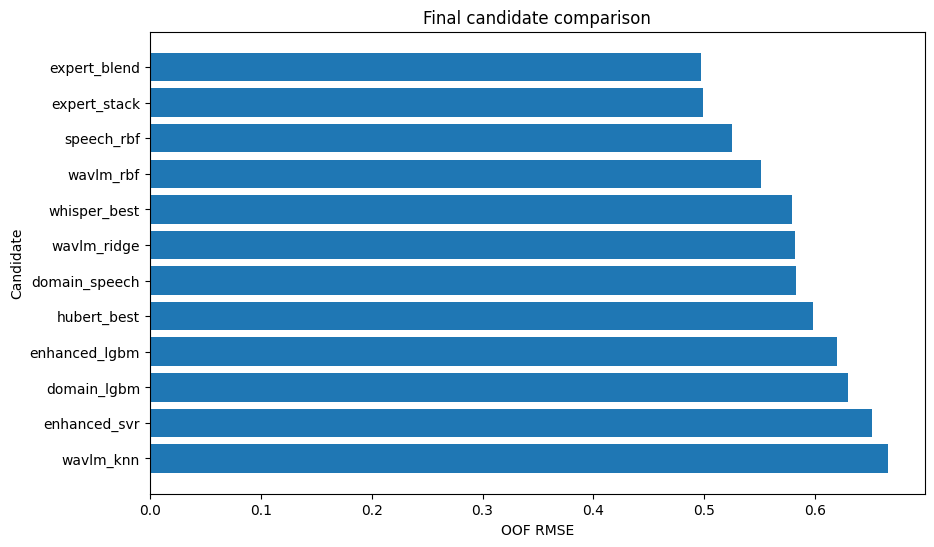

Best OOF candidate: RMSE=0.4968 | Pearson=0.9162
Best OOF model: expert_blend
Best OOF RMSE : 0.4968


In [39]:
FINAL_CANDIDATES = {
    "enhanced_lgbm": ENH_LGBM_OOF,
    "enhanced_svr": ENH_SVR_OOF,
    "wavlm_ridge": wavlm_oof_mean,
    "wavlm_rbf": WAVLM_RBF_OOF,
    "wavlm_knn": WAVLM_KNN_OOF,
    "whisper_best": WHISPER_BEST_OOF,
    "hubert_best": HUBERT_BEST_OOF,
    "speech_rbf": COMBINED_RBF_OOF,
    "domain_lgbm": DOMAIN_WEIGHTED_LGBM_OOF,
    "domain_speech": DOMAIN_WEIGHTED_SPEECH_OOF,
    "expert_stack": meta_stack_oof,
    "expert_blend": BEST_EXPERT_BLEND_OOF,
}

if USE_EXPERT_ISOTONIC:
    FINAL_CANDIDATES["expert_calibrated"] = calibrated_expert_oof

final_rows = [
    {
        "candidate": name,
        "rmse": rmse(y, pred),
        "pearson": pearson(y, pred),
    }
    for name, pred in FINAL_CANDIDATES.items()
]

final_results = (
    pd.DataFrame(final_rows)
    .sort_values("rmse")
    .reset_index(drop=True)
)

print(final_results.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
plot_final = final_results.sort_values("rmse")
plt.barh(plot_final["candidate"], plot_final["rmse"])
plt.xlabel("OOF RMSE")
plt.ylabel("Candidate")
plt.title("Final candidate comparison")
plt.gca().invert_yaxis()
plt.show()

BEST_OOF_NAME = final_results.iloc[0]["candidate"]
BEST_OOF_PRED = FINAL_CANDIDATES[BEST_OOF_NAME]

describe_result(
    "Best OOF candidate",
    y,
    BEST_OOF_PRED,
)

print("Best OOF model:", BEST_OOF_NAME)
print("Best OOF RMSE :", round(rmse(y, BEST_OOF_PRED), 4))


## 28. Fit the selected base models on all 769 training clips

The base models are fitted on all labeled clips before generating test predictions.

In [40]:
def fit_full_model(maker, X_train, X_test, sample_weight=None):
    model = maker()

    if sample_weight is None:
        model.fit(X_train, y)
    else:
        model.fit(
            X_train,
            y,
            sample_weight=sample_weight,
        )

    train_pred = np.clip(model.predict(X_train), 0, 5)
    test_pred = np.clip(model.predict(X_test), 0, 5)

    return model, train_pred, test_pred

FULL_TRAIN = {}
FULL_TEST = {}
FULL_MODELS = {}

base_full_specs = {
    "enh_lgbm": (tabular_lgbm, ENHANCED_HAND_X_train, ENHANCED_HAND_X_test, None),
    "enh_svr": (tabular_svr, ENHANCED_HAND_X_train, ENHANCED_HAND_X_test, None),
    "wavlm_ridge": (wavlm_ridge_mean, WAVLM_MEAN_TRAIN, WAVLM_MEAN_TEST, None),
    "wavlm_rbf": (wavlm_rbf_svr, WAVLM_MEAN_TRAIN, WAVLM_MEAN_TEST, None),
    "wavlm_knn": (wavlm_knn, WAVLM_MEAN_TRAIN, WAVLM_MEAN_TEST, None),
    "whisper_best": (wavlm_ridge_mean, WHISPER_BEST_TRAIN, WHISPER_BEST_TEST, None),
    "hubert_best": (wavlm_ridge_mean, HUBERT_BEST_TRAIN, HUBERT_BEST_TEST, None),
    "speech_rbf": (speech_rbf_svr, COMBINED_SPEECH_TRAIN, COMBINED_SPEECH_TEST, None),
    "speech3_rbf": (speech_rbf_svr, SPEECH3_TRAIN, SPEECH3_TEST, None),
    "domain_lgbm": (tabular_lgbm, ENHANCED_HAND_X_train, ENHANCED_HAND_X_test, domain_weights),
}

for name, (maker, Xtr, Xte, weights) in base_full_specs.items():
    model, trp, tep = fit_full_model(
        maker,
        Xtr,
        Xte,
        sample_weight=weights,
    )
    FULL_MODELS[name] = model
    FULL_TRAIN[name] = trp
    FULL_TEST[name] = tep

# Domain-weighted speech Ridge.
domain_speech_scaler = StandardScaler()
domain_speech_train_scaled = domain_speech_scaler.fit_transform(
    COMBINED_SPEECH_TRAIN
)
domain_speech_test_scaled = domain_speech_scaler.transform(
    COMBINED_SPEECH_TEST
)

domain_speech_model = Ridge(alpha=100.0)
domain_speech_model.fit(
    domain_speech_train_scaled,
    y,
    sample_weight=domain_weights,
)

FULL_MODELS["domain_speech"] = domain_speech_model
FULL_TRAIN["domain_speech"] = np.clip(
    domain_speech_model.predict(domain_speech_train_scaled),
    0,
    5,
)
FULL_TEST["domain_speech"] = np.clip(
    domain_speech_model.predict(domain_speech_test_scaled),
    0,
    5,
)

print("All full-data base models are ready.")


All full-data base models are ready.


## 29. Fit the expert stack and final prediction

In [41]:
# ---- Final stack (FIXED VERSION) ----
# Fix 1: the OOF table calls two models "whisper"/"hubert"; the full-data models are "whisper_best"/"hubert_best".
full_key = lambda name: OOF_TO_FULL.get(name, name)

FULL_BASE_MATRIX_TRAIN = np.column_stack([FULL_TRAIN[full_key(n)] for n in base_names])
FULL_BASE_MATRIX_TEST  = np.column_stack([FULL_TEST[full_key(n)]  for n in base_names])

META_INPUT_TRAIN = np.hstack([FULL_BASE_MATRIX_TRAIN, meta_extra_train])   # in-sample: only used to REPORT a train RMSE
META_INPUT_TEST  = np.hstack([FULL_BASE_MATRIX_TEST,  meta_extra_test])    # honest inputs for the test clips

# Fix 2: fit the meta-model on the OOF base predictions (STACK_INPUT).
# That is exactly the kind of input it was validated on. Fitting it on in-sample base predictions
# would teach it to trust models that have already memorised the training clips.
FINAL_META_MODEL = Pipeline([
    ("scale", StandardScaler()),
    ("model", RidgeCV(alphas=[1, 3, 10, 30, 100])),
])
FINAL_META_MODEL.fit(STACK_INPUT, y)

coef = pd.Series(FINAL_META_MODEL.named_steps["model"].coef_[:len(base_names)], index=base_names)
print("Meta-model weight on each base model (standardised inputs):")
print(coef.round(3).sort_values(ascending=False).to_string())

FULL_TRAIN["expert_stack"] = np.clip(FINAL_META_MODEL.predict(META_INPUT_TRAIN), 0, 5)
FULL_TEST["expert_stack"]  = np.clip(FINAL_META_MODEL.predict(META_INPUT_TEST), 0, 5)

b = full_key(best_base_name)
FULL_TRAIN["expert_blend"] = np.clip(
    BEST_EXPERT_BLEND_WEIGHT * FULL_TRAIN["expert_stack"] + (1.0 - BEST_EXPERT_BLEND_WEIGHT) * FULL_TRAIN[b], 0, 5)
FULL_TEST["expert_blend"] = np.clip(
    BEST_EXPERT_BLEND_WEIGHT * FULL_TEST["expert_stack"] + (1.0 - BEST_EXPERT_BLEND_WEIGHT) * FULL_TEST[b], 0, 5)

if USE_EXPERT_ISOTONIC:
    final_iso = IsotonicRegression(y_min=0, y_max=5, out_of_bounds="clip")
    final_iso.fit(BEST_EXPERT_BLEND_OOF, y)          # calibration learned from OOF predictions
    FULL_TRAIN["expert_calibrated"] = np.clip(final_iso.predict(FULL_TRAIN["expert_blend"]), 0, 5)
    FULL_TEST["expert_calibrated"]  = np.clip(final_iso.predict(FULL_TEST["expert_blend"]), 0, 5)

FULL_NAME_MAP = {
    "enhanced_lgbm": "enh_lgbm", "enhanced_svr": "enh_svr", "wavlm_ridge": "wavlm_ridge",
    "wavlm_rbf": "wavlm_rbf", "wavlm_knn": "wavlm_knn", "whisper_best": "whisper_best",
    "hubert_best": "hubert_best", "speech_rbf": "speech_rbf", "speech3_rbf": "speech3_rbf",
    "domain_lgbm": "domain_lgbm", "domain_speech": "domain_speech",
    "expert_stack": "expert_stack", "expert_blend": "expert_blend", "expert_calibrated": "expert_calibrated",
}
FINAL_FULL_KEY = FULL_NAME_MAP[BEST_OOF_NAME]

# Rounding to 2 decimals (harmless: changes each prediction by at most 0.005).
selected_train_pred = np.clip(np.round(FULL_TRAIN[FINAL_FULL_KEY], 2), 0, 5)
selected_test_pred  = np.clip(np.round(FULL_TEST[FINAL_FULL_KEY], 2), 0, 5)

print("=" * 70)
print("FINAL MODEL:", BEST_OOF_NAME, "| full key:", FINAL_FULL_KEY)
print("TRAIN RMSE (required):", round(rmse(y, selected_train_pred), 4))
print("TRAIN Pearson        :", round(pearson(y, selected_train_pred), 4))
print("OOF RMSE (honest)    :", round(rmse(y, BEST_OOF_PRED), 4))
print("OOF Pearson (honest) :", round(pearson(y, BEST_OOF_PRED), 4))
print("TEST mean / std      :", round(float(selected_test_pred.mean()), 4), "/", round(float(selected_test_pred.std()), 4))
print("TEST min / max       :", round(float(selected_test_pred.min()), 4), "/", round(float(selected_test_pred.max()), 4))
print("=" * 70)


Meta-model weight on each base model (standardised inputs):
speech3_rbf      0.261
wavlm_rbf        0.168
speech_rbf       0.166
enh_svr          0.155
hubert           0.132
wavlm_ridge      0.077
enh_lgbm         0.075
whisper          0.069
domain_lgbm      0.053
domain_speech    0.032
wavlm_knn       -0.041
FINAL MODEL: expert_blend | full key: expert_blend
TRAIN RMSE (required): 0.1033
TRAIN Pearson        : 0.9966
OOF RMSE (honest)    : 0.4968
OOF Pearson (honest) : 0.9162
TEST mean / std      : 3.2343 / 0.8509
TEST min / max       : 1.58 / 5.0


## 30. Final visual checks

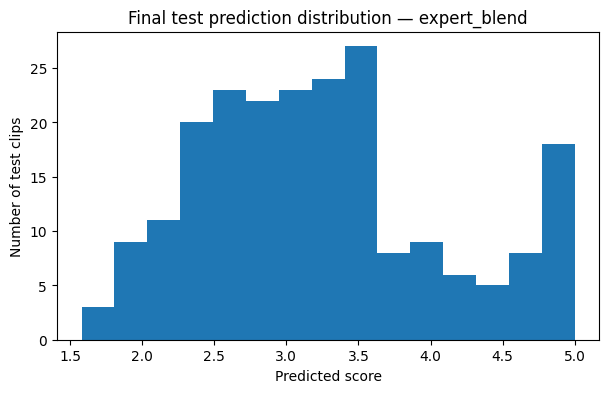

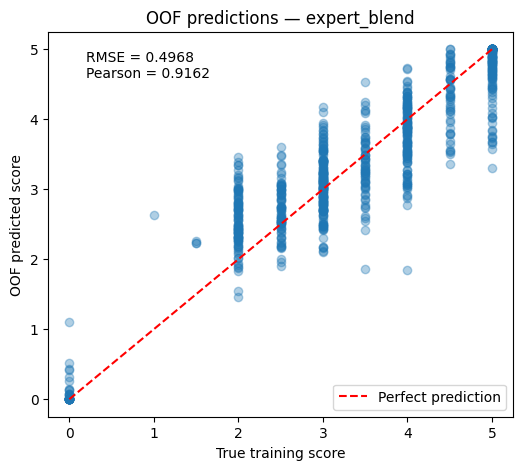

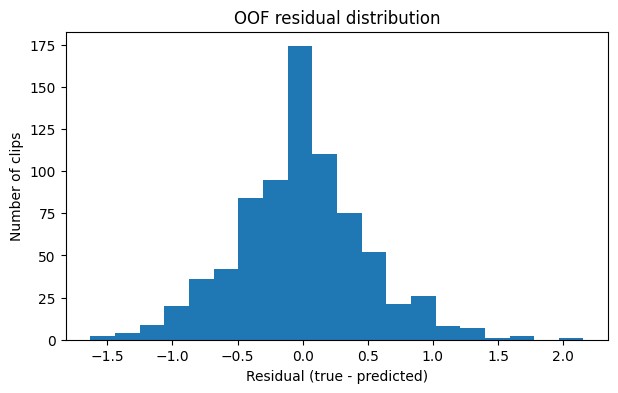

In [42]:
plt.figure(figsize=(7, 4))
plt.hist(
    selected_test_pred,
    bins=15,
)
plt.xlabel("Predicted score")
plt.ylabel("Number of test clips")
plt.title(f"Final test prediction distribution — {BEST_OOF_NAME}")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(
    y,
    BEST_OOF_PRED,
    alpha=0.35,
)
plt.plot(
    [0, 5],
    [0, 5],
    "r--",
    label="Perfect prediction",
)
plt.xlabel("True training score")
plt.ylabel("OOF predicted score")
plt.title(f"OOF predictions — {BEST_OOF_NAME}")
plt.text(
    0.2,
    4.6,
    f"RMSE = {rmse(y, BEST_OOF_PRED):.4f}\n"
    f"Pearson = {pearson(y, BEST_OOF_PRED):.4f}",
)
plt.legend()
plt.show()

residuals = y - BEST_OOF_PRED

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=20)
plt.xlabel("Residual (true - predicted)")
plt.ylabel("Number of clips")
plt.title("OOF residual distribution")
plt.show()


## 31. Submission

The packaged sample submission has a known mismatch with the 216-row `test.csv`.

The actual test CSV contains 216 rows, and all 216 filenames exist in the test audio folder. The submission is therefore written in `test.csv` order.

In [57]:
submission = pd.DataFrame({
    ID_COL: test_df[ID_COL].astype(str),
    TARGET_COL: np.clip(selected_test_pred, 0, 5),
})

assert len(submission) == len(test_df) == 216
assert submission[ID_COL].is_unique
assert submission[TARGET_COL].notna().all()
assert submission[TARGET_COL].between(0, 5).all()

submission_path = "/kaggle/working/submission2.csv"

submission.to_csv(
    submission_path,
    index=False,
)

print("Submission shape:", submission.shape)
print("NaN predictions:", int(submission[TARGET_COL].isna().sum()))
print(submission.head(10))
print("Saved:", submission_path)


Submission shape: (216, 2)
NaN predictions: 0
        filename  label
0  audio_128.wav   3.13
1  audio_156.wav   4.13
2   audio_19.wav   4.54
3  audio_108.wav   1.87
4  audio_206.wav   2.16
5  audio_161.wav   2.92
6  audio_215.wav   2.82
7  audio_213.wav   1.70
8   audio_11.wav   3.30
9  audio_155.wav   3.61
Saved: /kaggle/working/submission2.csv


In [59]:
# Sanity checks on the final file and on the stack
chk = pd.read_csv(submission_path)
print("file:", chk.shape, chk.columns.tolist())
print("all values have at most 2 decimals:", bool((chk[TARGET_COL].round(2) == chk[TARGET_COL]).all()))
print("same ids as test.csv, same order:", bool((chk[ID_COL].values == test_df[ID_COL].astype(str).values).all()))

# Does the final answer stay close to the best single model? (a huge gap would be a red flag)
ref = FULL_TEST["speech_rbf"]
print("corr with best single model on test:", round(np.corrcoef(selected_test_pred, ref)[0, 1], 3),
      "| mean abs difference:", round(float(np.abs(selected_test_pred - ref).mean()), 3))
print("spread of final test predictions:", round(float(selected_test_pred.std()), 3),
      "| spread of OOF predictions:", round(float(BEST_OOF_PRED.std()), 3))

# How noisy is the stack score? Repeat the meta-stage CV with 10 different fold splits.
vals = []
for s in range(10):
    kk = KFold(5, shuffle=True, random_state=100 + s)
    o = np.zeros(len(y))
    for tr, va in kk.split(STACK_INPUT):
        m = Pipeline([("scale", StandardScaler()), ("model", RidgeCV(alphas=[1, 3, 10, 30, 100]))])
        m.fit(STACK_INPUT[tr], y[tr]); o[va] = m.predict(STACK_INPUT[va])
    vals.append(rmse(y, np.clip(o, 0, 5)))
print(f"stack OOF RMSE over 10 meta-splits: {np.mean(vals):.4f} +- {np.std(vals):.4f}")
print("Note: this only measures noise in the last stage. The base models and the blend/calibration choices")
print("were selected on the same OOF scores, so the true leaderboard score is usually somewhat higher.")


file: (216, 2) ['filename', 'label']
all values have at most 2 decimals: True
same ids as test.csv, same order: True
corr with best single model on test: 0.98 | mean abs difference: 0.136
spread of final test predictions: 0.851 | spread of OOF predictions: 1.113
stack OOF RMSE over 10 meta-splits: 0.4985 +- 0.0010
Note: this only measures noise in the last stage. The base models and the blend/calibration choices
were selected on the same OOF scores, so the true leaderboard score is usually somewhat higher.


## 32. Kaggle command

```bash
kaggle competitions submit -c shl-hiring-assessment-2026 -f /kaggle/working/submission.csv -m "WavLM + Whisper + HuBERT + grammar + acoustic features with leakage-safe OOF stacking"
```

The previous external benchmark is **0.4401 RMSE**. That is the leaderboard number to beat.
Rounding to 2 decimals does not lower the RMSE; it only keeps the file tidy.


## 33. Short SHL report

### Problem
Predict a 0–5 grammar score from spoken English audio.

### Pipeline
`audio -> Whisper transcript + word timing + acoustic features -> grammar/text features + frozen speech embeddings -> small regressors -> leakage-safe OOF stack -> submission`

### Main feature groups
- **Text:** word counts, repetitions, fillers, LanguageTool errors, GPT-2 perplexity, GPT-2 token surprisal, RoBERTa-CoLA acceptability.
- **Speech delivery:** duration, speech ratio, pauses, speaking rate, pitch, energy, spectral features, MFCCs, Whisper word timing and ASR confidence.
- **Speech embeddings:** WavLM, Whisper encoder and HuBERT.

### New ideas in this version
- RBF-SVR and KNN on WavLM embeddings.
- HuBERT as an independent speech representation.
- Unsupervised train/test density-ratio weighting.
- Cross-fitted meta stacking.
- Controlled rounding check.

### Validation
I use the same 5-fold split for model comparison. Base predictions entering the stack are OOF, and the stack itself is cross-fitted before evaluation.

### Leakage rules
I never use test labels and I do not use the numeric part of the filename as a feature.